In [1]:
import bagpipes as pipes
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches
mpl.rcParams['font.family'] = 'serif'
config = {
    "font.size": 18,
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
plt.rcParams.update(config)
from matplotlib.ticker import AutoMinorLocator


from astropy import units as u
from tqdm import tqdm
from scipy.integrate import quad



import numpy as np
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.lines import Line2D
from tqdm import tqdm # 如果不在notebook运行，请改为 from tqdm import tqdm


ModuleNotFoundError: No module named 'bagpipes'

---
## Here is the constant sfh model for different ages.

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:07<00:00,  1.41s/it]


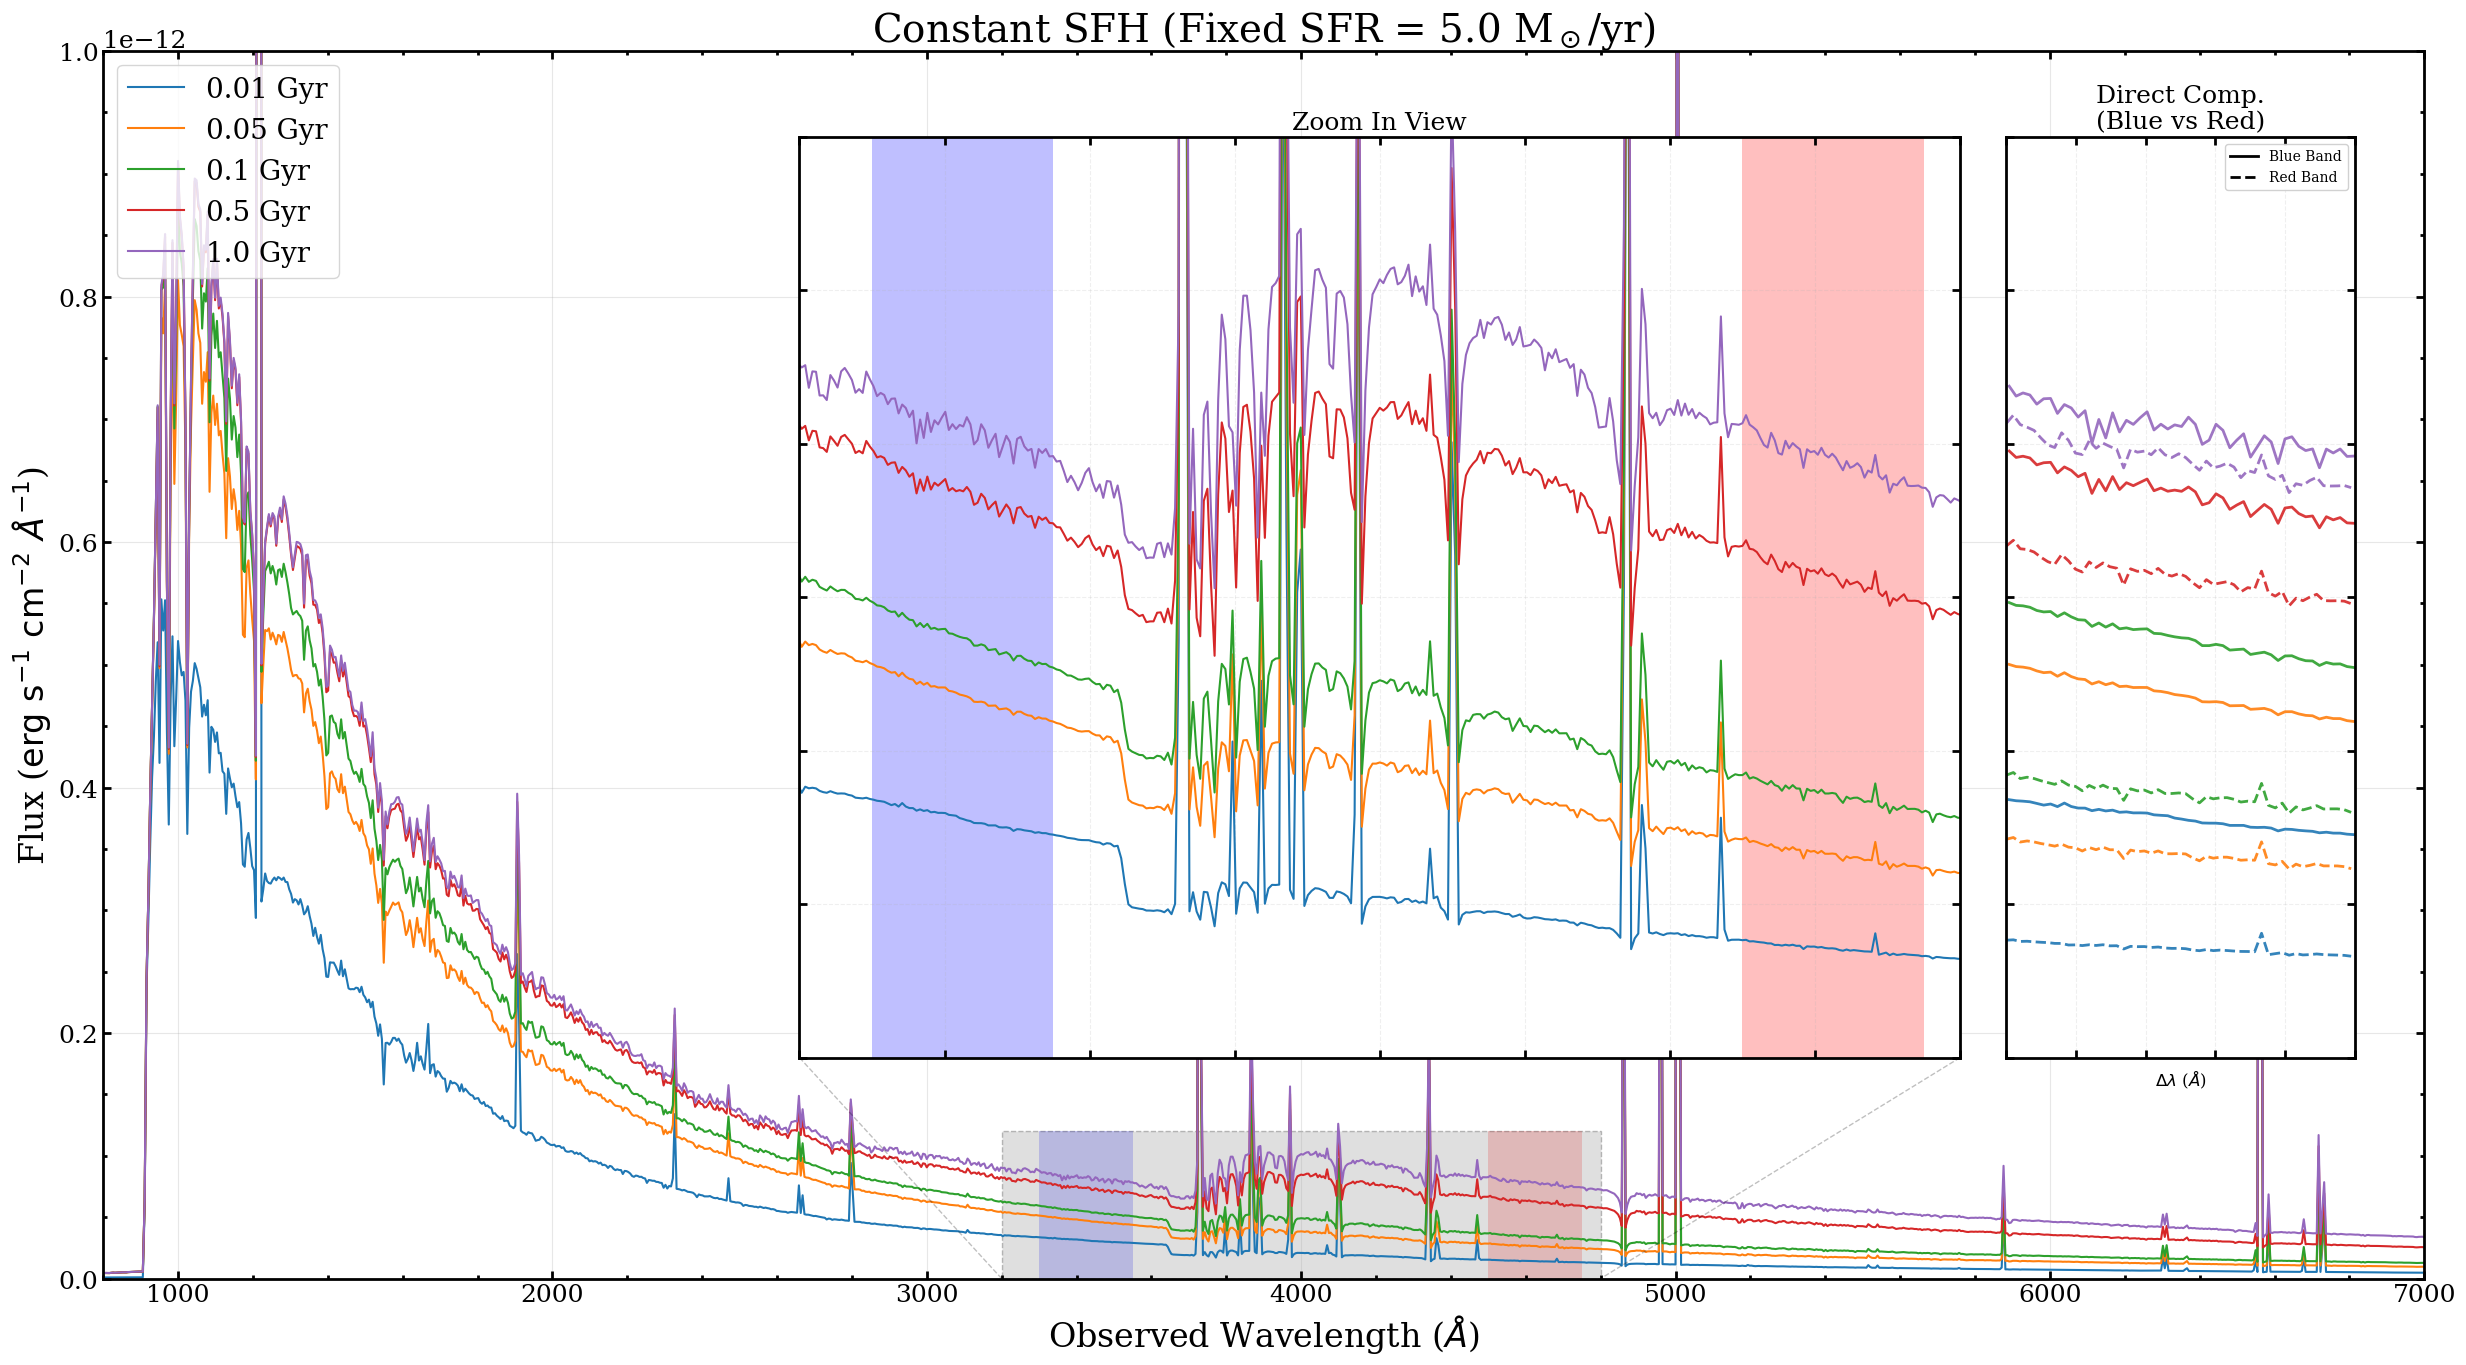

In [2]:
age_list=[0.01,0.05,0.1,0.5,1.0]
target_sfr=5.0
constant_sfh = {}
constant_sfh["age_min"] = 0.0
constant_sfh["metallicity"] = 0.2

nebular = {}
nebular["logU"] = -2.5

model_components = {}
model_components["redshift"] = 0.01
model_components["constant"] = constant_sfh
model_components["nebular"] = nebular
waves_arrays=np.array([])
flux_arrays=np.array([])
for age in tqdm(age_list):

# 1. 更新年龄
    model_components["constant"]["age_max"] = age

    # 2. 更新质量 (Mass = SFR * Age)
    total_mass = target_sfr * (age * 1e9)
    model_components["constant"]["massformed"] = np.log10(total_mass)

    # 3. 生成模型 (只覆盖 3000-5000A 即可)
    model = pipes.model_galaxy(model_components, spec_wavs=np.arange(500, 8000, 5))
    wave = model.spectrum[:, 0]/1.01
    flux = model.spectrum[:, 1]*1.01
    if waves_arrays.size==0:
        waves_arrays=wave
        flux_arrays=flux
    else:
        waves_arrays=np.column_stack((waves_arrays,wave))
        flux_arrays=np.column_stack((flux_arrays,flux))


fig, ax = plt.subplots(figsize=(25, 14))


for i in range(len(age_list)):
    ax.plot(waves_arrays[:,i], flux_arrays[:,i], label=f"{age_list[i]} Gyr")

ax.set_xlabel(f"Observed Wavelength ($\AA$)")
ax.set_ylabel("Flux ($\\text{erg}\ \\text{s}^{-1}\ \\text{cm}^{-2}\ \\AA^{-1}$)")
ax.set_title(f"Constant SFH (Fixed SFR = {target_sfr} M$_\odot$/yr)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1e-12)
ax.set_xlim(800,7000)

rect_blue = patches.Rectangle((3300, 0), 250, 1.2e-13, facecolor='blue', alpha=0.2, edgecolor='none')
rect_red  = patches.Rectangle((4500, 0), 250, 1.2e-13, facecolor='red', alpha=0.2, edgecolor='none')
ax.add_patch(rect_blue)
ax.add_patch(rect_red)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())



axins_zoom = ax.inset_axes([0.3, 0.18, 0.5, 0.75])
axins_comp = ax.inset_axes([0.82, 0.18, 0.15, 0.75])


ylim_inset = 1.2e-13


for i in range(len(age_list)):
    axins_zoom.plot(waves_arrays[:,i], flux_arrays[:,i])

axins_zoom.fill_between([3300, 3550], 0, ylim_inset, facecolor='blue', alpha=0.25)
axins_zoom.fill_between([4500, 4750], 0, ylim_inset, facecolor='red', alpha=0.25)

axins_zoom.set_xlim(3200, 4800)
axins_zoom.set_ylim(0, ylim_inset)
axins_zoom.tick_params(axis='both', labelsize=12)
axins_zoom.set_title("Zoom In View", fontsize=18)
axins_zoom.grid(True, alpha=0.2, linestyle='--')
axins_zoom.set_xticklabels([])
axins_zoom.set_yticklabels([])

mark_inset(ax, axins_zoom, loc1=3, loc2=4, fc="gray", alpha=0.25, ec="k", lw=1, linestyle='--')


blue_start = 3300
red_start = 4500
span = 250 # 两个区域都是300A宽

for i in range(len(age_list)):
    # 获取颜色以便匹配
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]

    w = waves_arrays[:,i]
    f = flux_arrays[:,i]

    # --- 蓝色部分 (实线) ---
    mask_b = (w >= blue_start) & (w <= blue_start + span)
    axins_comp.plot(w[mask_b] - blue_start, f[mask_b],
                    color=color, linestyle='-', linewidth=2, alpha=0.9)

    # --- 红色部分 (虚线) ---
    mask_r = (w >= red_start) & (w <= red_start + span)
    axins_comp.plot(w[mask_r] - red_start, f[mask_r],
                    color=color, linestyle='--', linewidth=2, alpha=0.9)

# 设置范围和样式
axins_comp.set_xlim(0, span)
axins_comp.set_ylim(0, ylim_inset)
axins_comp.set_title("Direct Comp.\n(Blue vs Red)", fontsize=18)
axins_comp.set_xlabel(r"$\Delta \lambda$ ($\AA$)", fontsize=12)

# 为了美观，右图的Y轴刻度可以隐藏（因为和左图对齐），或者保留看你喜好
axins_comp.set_yticklabels([])
axins_comp.tick_params(axis='x', labelsize=12)
axins_comp.grid(True, alpha=0.2, linestyle='--')
axins_comp.set_xticklabels([])
axins_comp.set_yticklabels([])

# 添加一个小图例解释线型
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='k', lw=2, label='Blue Band', linestyle='-'),
                   Line2D([0], [0], color='k', lw=2, label='Red Band', linestyle='--')]
axins_comp.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig("bagpipes_constant_SFR.pdf")
plt.show()

正在计算...


100%|██████████| 5/5 [00:06<00:00,  1.39s/it]


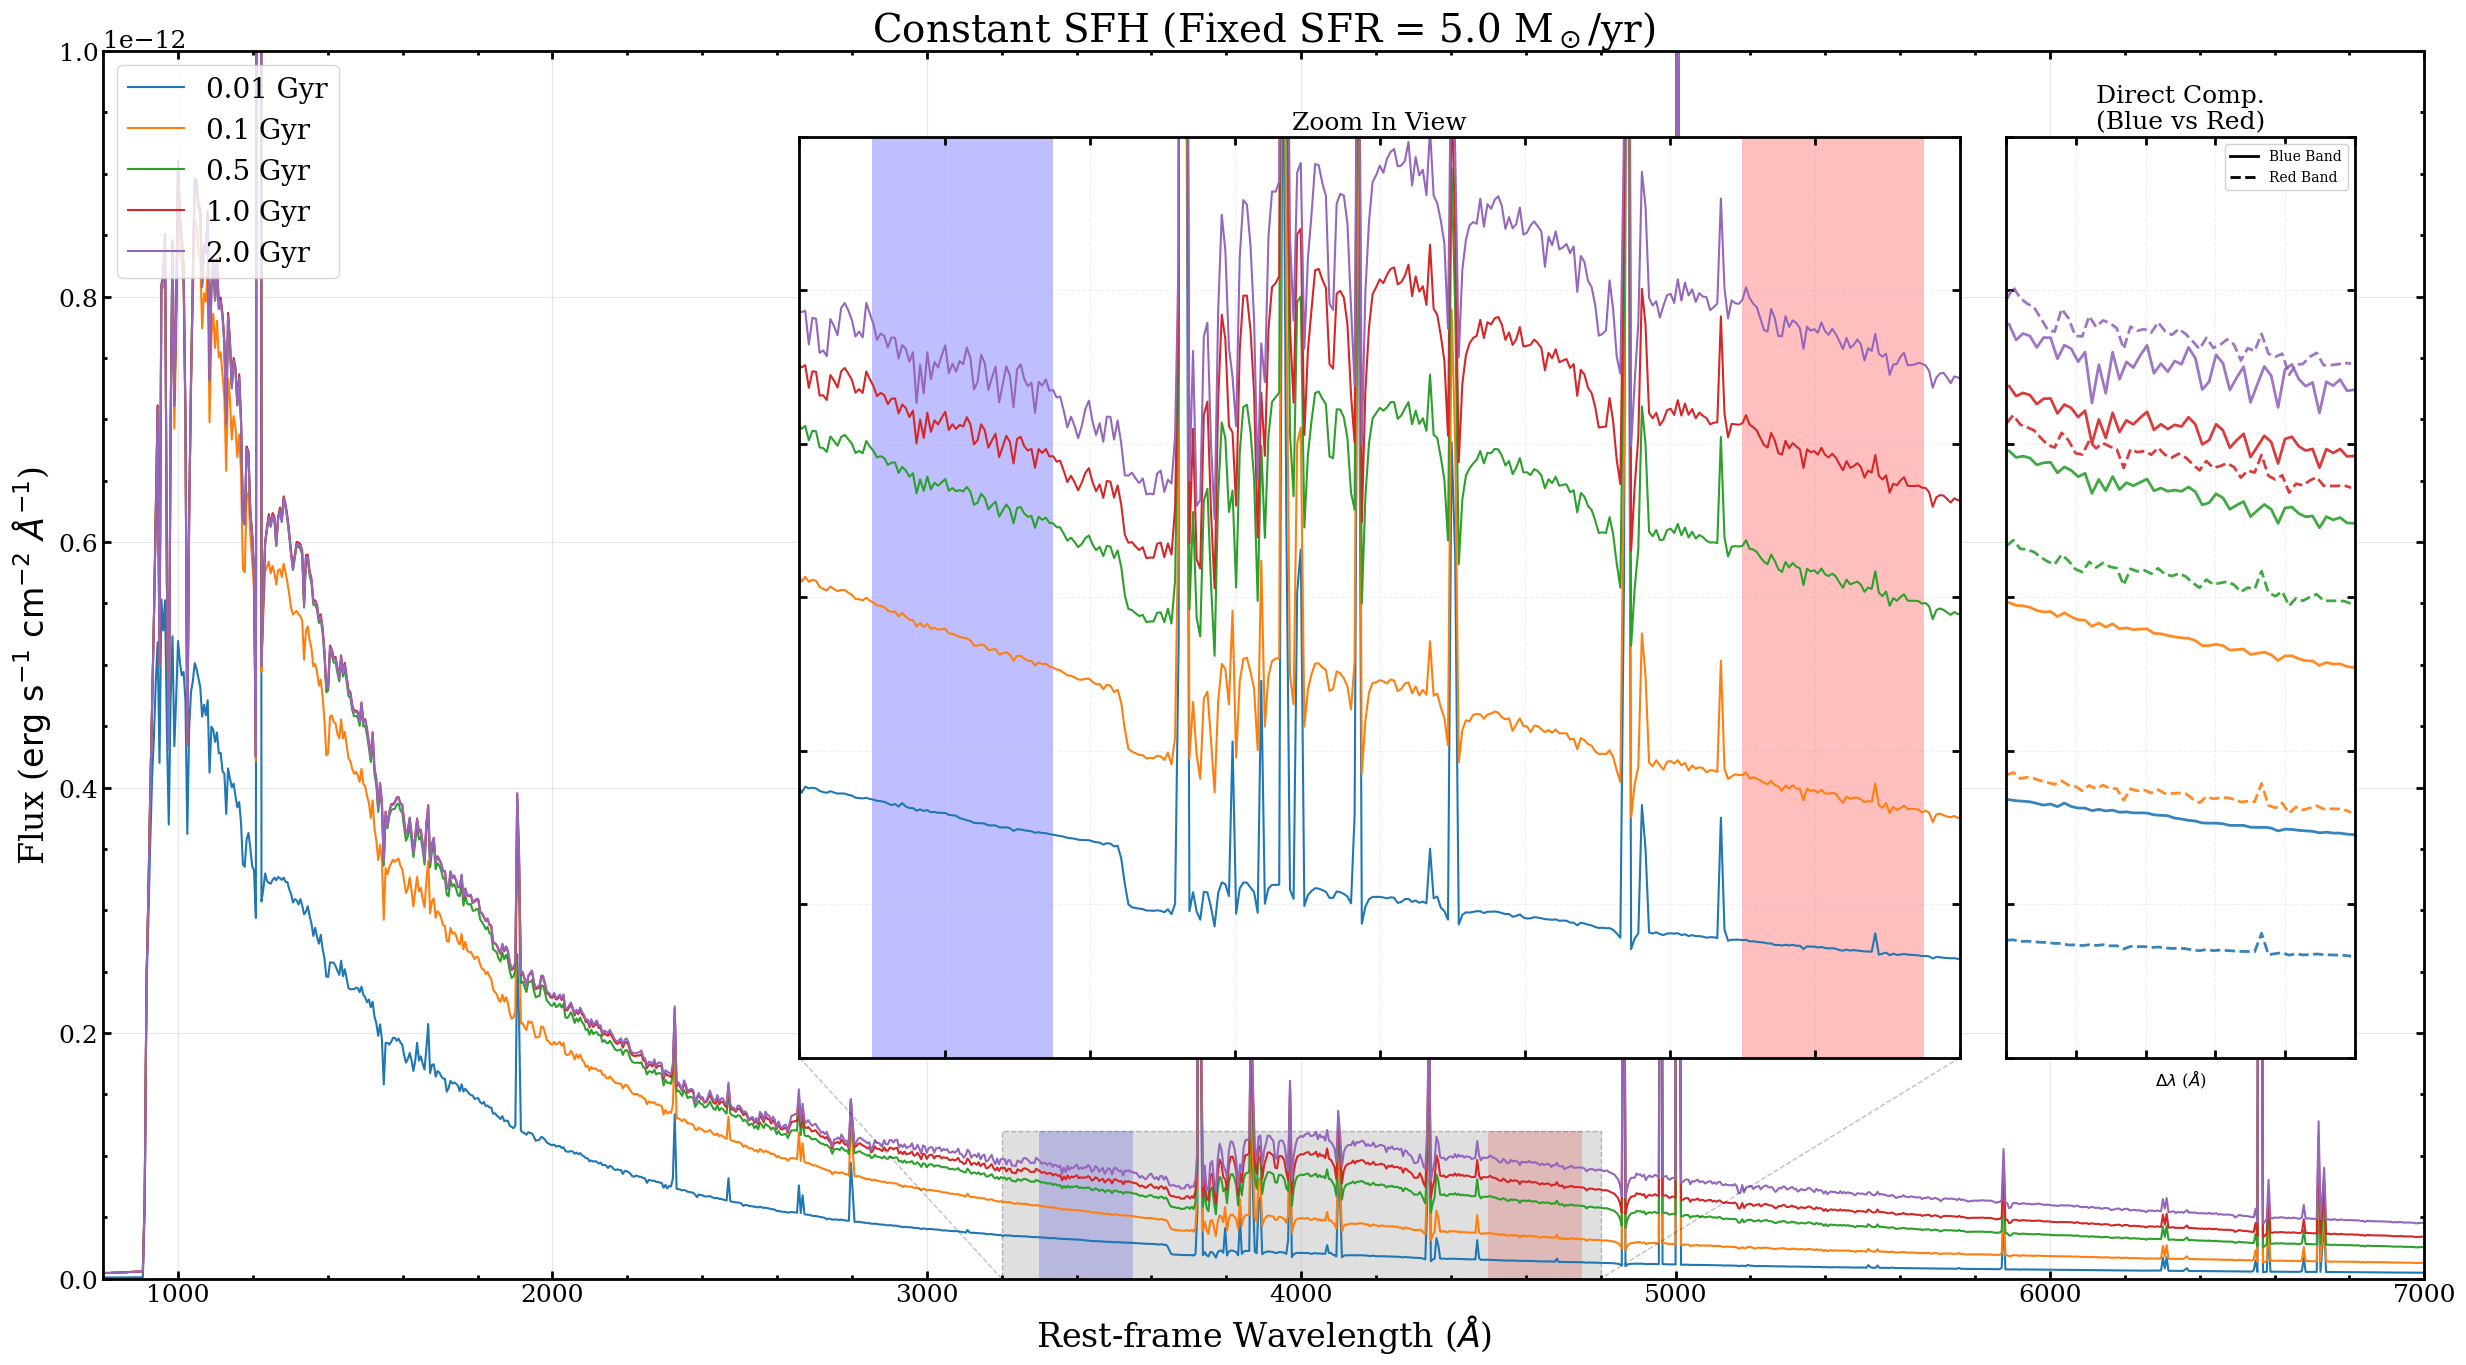

In [38]:
import numpy as np
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.lines import Line2D
from tqdm import tqdm # 如果不在notebook运行，请改为 from tqdm import tqdm


# --- 1. 参数设置 ---
age_list = [0.01, 0.1, 0.5, 1.0, 2.0]
target_sfr = 5.0
z = 0.01  # 定义红移变量

constant_sfh = {}
constant_sfh["age_min"] = 0.0
constant_sfh["metallicity"] = 0.2

nebular = {}
nebular["logU"] = -2.5

model_components = {}
model_components["redshift"] = z
model_components["constant"] = constant_sfh
model_components["nebular"] = nebular

# --- 2. 循环计算 ---
# 使用列表收集数据，比在循环中反复 stack 更安全且快
waves_list = []
flux_list = []

print("正在计算...")
for age in tqdm(age_list):
    # 1. 更新年龄
    model_components["constant"]["age_max"] = age

    # 2. 更新质量 (Mass = SFR * Age)
    total_mass = target_sfr * (age * 1e9)
    model_components["constant"]["massformed"] = np.log10(total_mass)

    # 3. 生成模型
    model = pipes.model_galaxy(model_components, spec_wavs=np.arange(500, 8000, 5))

    # 4. 红移校准 (Observed -> Rest Frame)
    # 使用变量 (1+z) 替代硬编码的 1.01
    wave = model.spectrum[:, 0] / (1 + z)
    flux = model.spectrum[:, 1] * (1 + z)

    waves_list.append(wave)
    flux_list.append(flux)

# 将列表转换为 numpy 数组 (Shape: N_points x N_ages)
waves_arrays = np.column_stack(waves_list)
flux_arrays = np.column_stack(flux_list)


# --- 3. 绘图 (严格保持尺寸和字体大小) ---
fig, ax = plt.subplots(figsize=(25, 14)) # 保持原尺寸

for i in range(len(age_list)):
    ax.plot(waves_arrays[:,i], flux_arrays[:,i], label=f"{age_list[i]} Gyr")

# 修正标签内容以符合物理含义 (Rest-frame)，但保持默认字体大小
ax.set_xlabel(r"Rest-frame Wavelength ($\AA$)")
ax.set_ylabel("Flux ($\\text{erg}\ \\text{s}^{-1}\ \\text{cm}^{-2}\ \\AA^{-1}$)")
ax.set_title(f"Constant SFH (Fixed SFR = {target_sfr} M$_\odot$/yr)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1e-12)
ax.set_xlim(800, 7000)

# 矩形区域
rect_blue = patches.Rectangle((3300, 0), 250, 1.2e-13, facecolor='blue', alpha=0.2, edgecolor='none')
rect_red  = patches.Rectangle((4500, 0), 250, 1.2e-13, facecolor='red', alpha=0.2, edgecolor='none')
ax.add_patch(rect_blue)
ax.add_patch(rect_red)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# --- 插图 1: Zoom In ---
axins_zoom = ax.inset_axes([0.3, 0.18, 0.5, 0.75])
axins_comp = ax.inset_axes([0.82, 0.18, 0.15, 0.75])

ylim_inset = 1.2e-13

for i in range(len(age_list)):
    axins_zoom.plot(waves_arrays[:,i], flux_arrays[:,i])

axins_zoom.fill_between([3300, 3550], 0, ylim_inset, facecolor='blue', alpha=0.25)
axins_zoom.fill_between([4500, 4750], 0, ylim_inset, facecolor='red', alpha=0.25)

axins_zoom.set_xlim(3200, 4800)
axins_zoom.set_ylim(0, ylim_inset)
axins_zoom.tick_params(axis='both', labelsize=12) # 保持原设定
axins_zoom.set_title("Zoom In View", fontsize=18) # 保持原设定
axins_zoom.grid(True, alpha=0.2, linestyle='--')
axins_zoom.set_xticklabels([])
axins_zoom.set_yticklabels([])

mark_inset(ax, axins_zoom, loc1=3, loc2=4, fc="gray", alpha=0.25, ec="k", lw=1, linestyle='--')


# --- 插图 2: Direct Comparison ---
blue_start = 3300
red_start = 4500
span = 250

for i in range(len(age_list)):
    # 获取颜色以便匹配
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]

    w = waves_arrays[:,i]
    f = flux_arrays[:,i]

    # --- 蓝色部分 (实线) ---
    mask_b = (w >= blue_start) & (w <= blue_start + span)
    axins_comp.plot(w[mask_b] - blue_start, f[mask_b],
                    color=color, linestyle='-', linewidth=2, alpha=0.9)

    # --- 红色部分 (虚线) ---
    mask_r = (w >= red_start) & (w <= red_start + span)
    axins_comp.plot(w[mask_r] - red_start, f[mask_r],
                    color=color, linestyle='--', linewidth=2, alpha=0.9)

# 设置范围和样式
axins_comp.set_xlim(0, span)
axins_comp.set_ylim(0, ylim_inset)
axins_comp.set_title("Direct Comp.\n(Blue vs Red)", fontsize=18) # 保持原设定
axins_comp.set_xlabel(r"$\Delta \lambda$ ($\AA$)", fontsize=12) # 保持原设定

axins_comp.set_yticklabels([])
axins_comp.tick_params(axis='x', labelsize=12) # 保持原设定
axins_comp.grid(True, alpha=0.2, linestyle='--')
axins_comp.set_xticklabels([])
axins_comp.set_yticklabels([])

# 图例
legend_elements = [Line2D([0], [0], color='k', lw=2, label='Blue Band', linestyle='-'),
                   Line2D([0], [0], color='k', lw=2, label='Red Band', linestyle='--')]
axins_comp.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig("bagpipes_constant_SFR_restframe.pdf")
plt.show()

### Here is the different SFR with time.

正在计算颜色比值 (Blue/Red Ratio)...


SFR = 1.0 M_sun/yr 完成。


SFR = 5.0 M_sun/yr 完成。


SFR = 10.0 M_sun/yr 完成。


SFR = 50.0 M_sun/yr 完成。


Exception ignored in: <function tqdm.__del__ at 0x7f527be019e0>
Traceback (most recent call last):
  File "/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


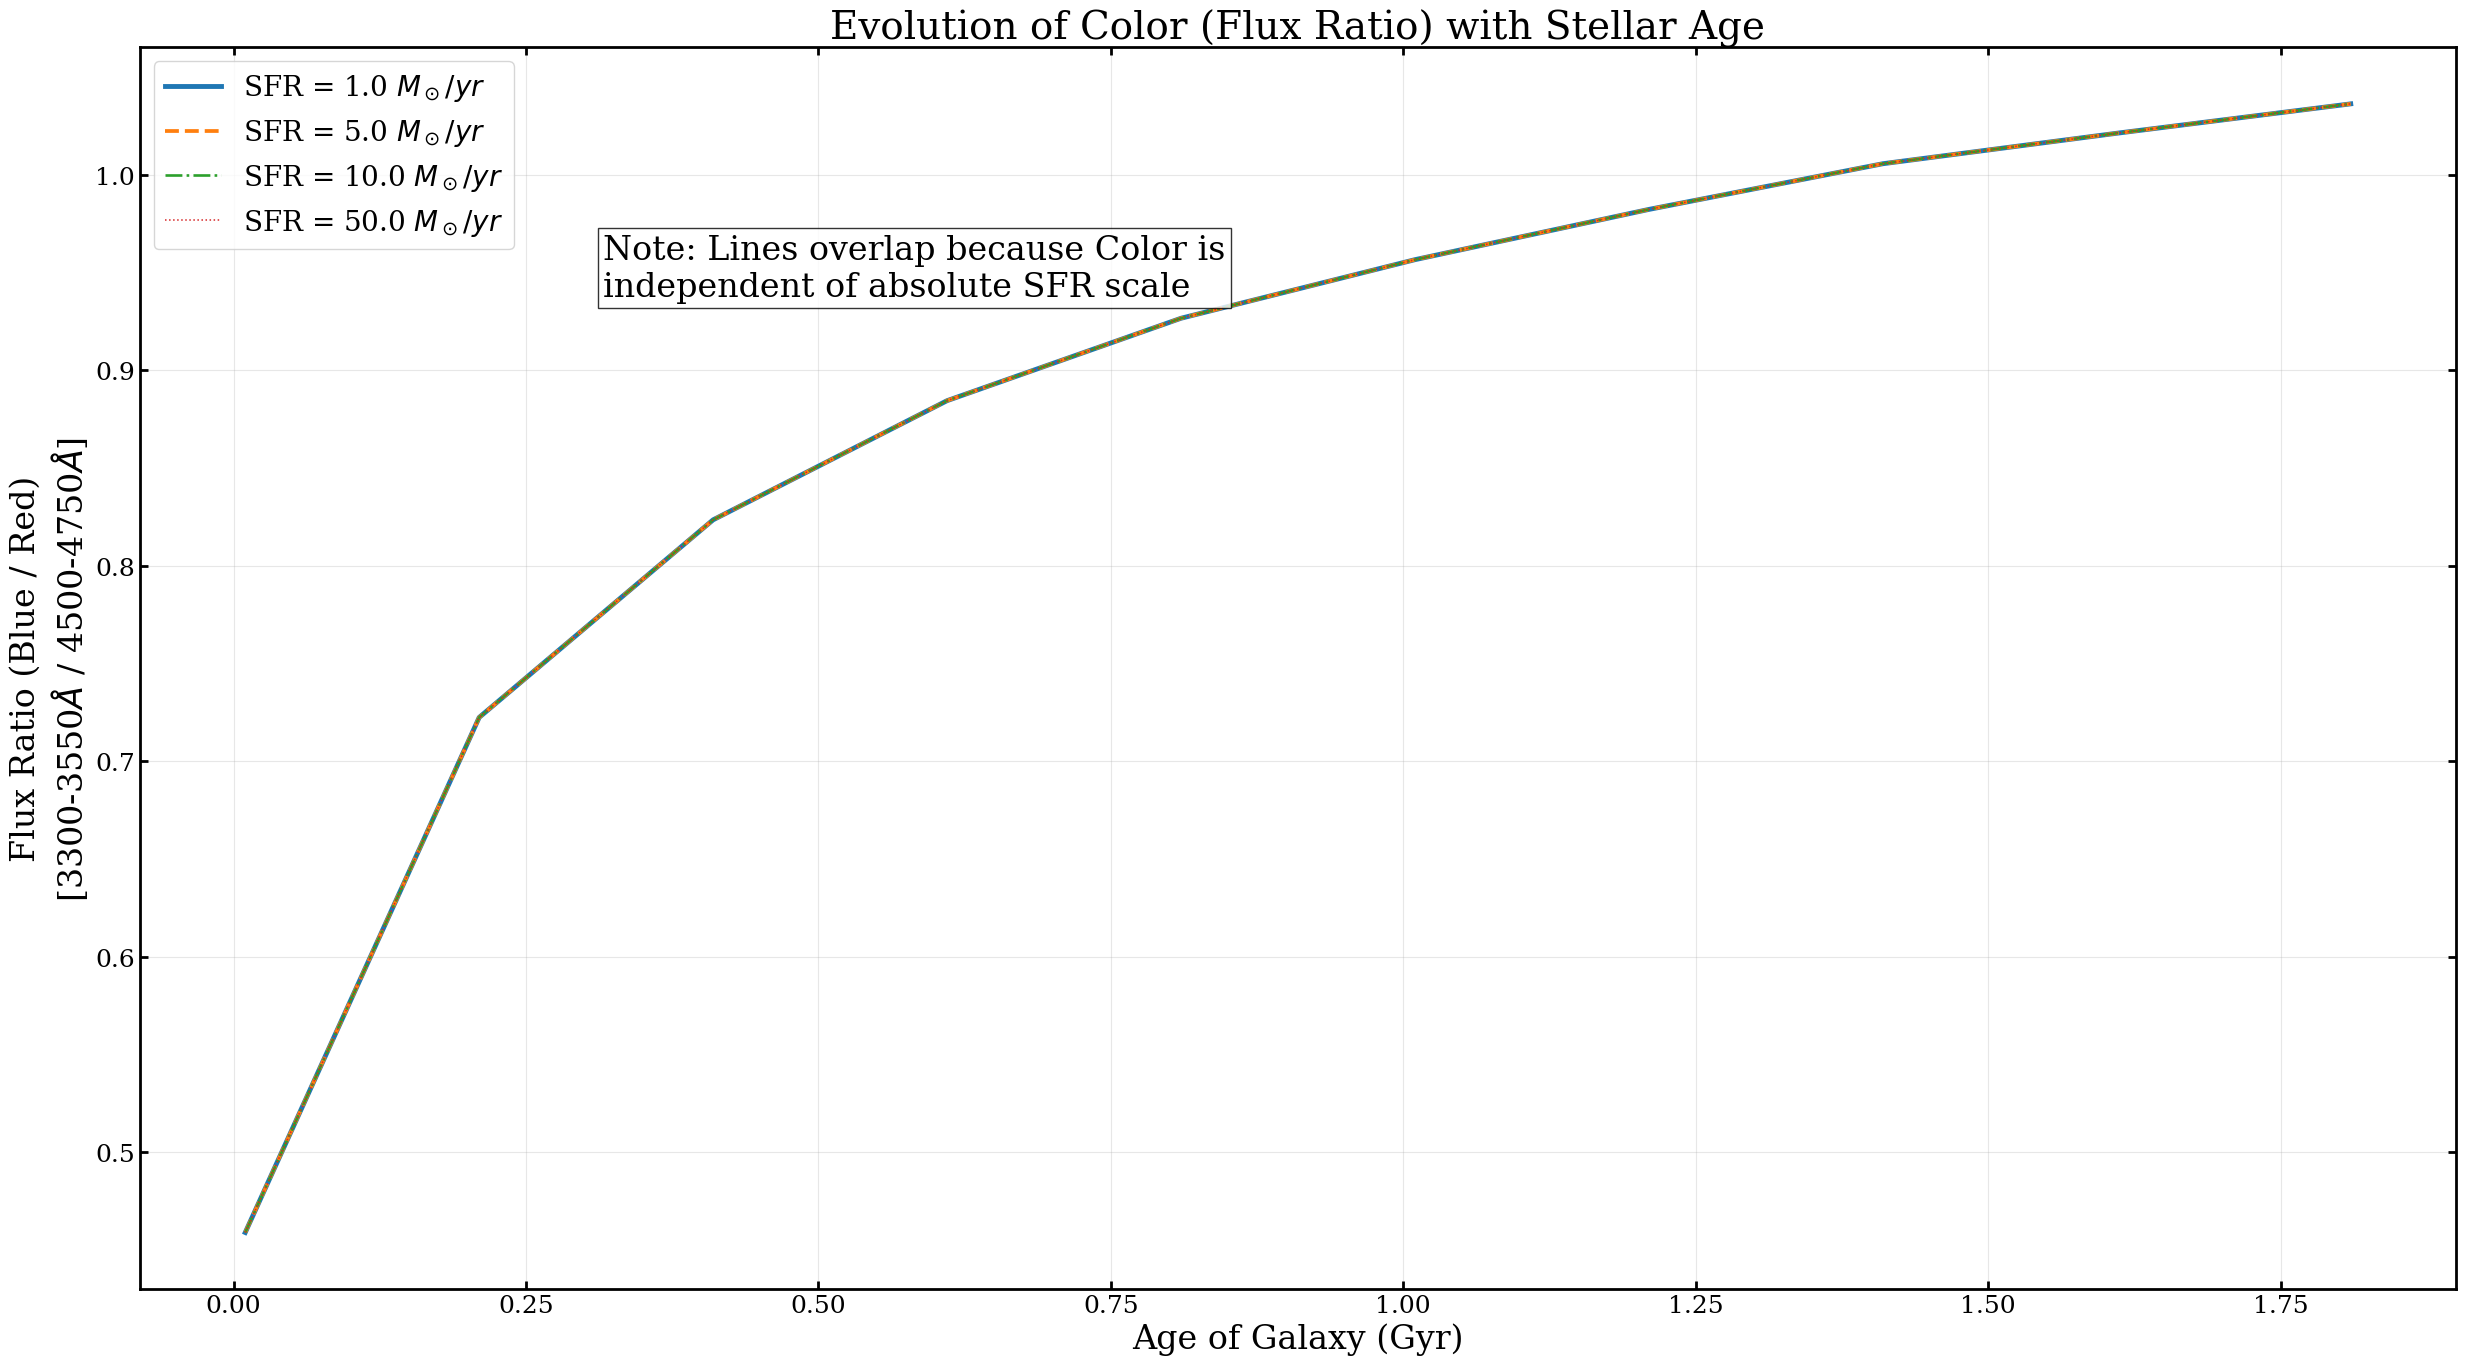

In [20]:
# --- 1. 定义参数 ---
# 我们选择几个跨度较大的 SFR，来验证比值是否与 SFR 无关
sfr_list = [1.0, 5.0, 10.0, 50.0]
# 基础模型配置
constant_sfh = {}
constant_sfh["age_min"] = 0.0
constant_sfh["metallicity"] = 0.2

nebular = {}
nebular["logU"] = -2.5

model_components = {}
model_components["redshift"] = 0.05
model_components["constant"] = constant_sfh
model_components["nebular"] = nebular

# --- 2. 准备循环 ---
age_list = np.arange(0.01, 2.01, 0.2) # 从 10 Myr 到 2 Gyr

# 定义波长区间
b_left, b_right = 3300, 3550
r_left, r_right = 4500, 4750

# 绘图设置
plt.figure(figsize=(25, 14))
# 使用不同的线型，以便如果它们重合，我们能看出来
linestyles = ['-', '--', '-.', ':']

print("正在计算颜色比值 (Blue/Red Ratio)...")

for i, target_sfr in enumerate(sfr_list): # 保持外层 i 不变

    ratios = []

    for age in tqdm(age_list, desc=f"SFR = {target_sfr}", leave=False):

        model_components["constant"]["age_max"] = age
        total_mass = target_sfr * (age * 1e9)
        model_components["constant"]["massformed"] = np.log10(total_mass)

        model = pipes.model_galaxy(model_components, spec_wavs=np.arange(3000, 5000, 50))
        wave = model.spectrum[:, 0]/1.05
        flux = model.spectrum[:, 1]*1.05

        # Blue Integral
        fluxsum = 0
        wavesum = 0
        mask_b = (wave >= b_left) & (wave <= b_right)
        flux_b = flux[mask_b]
        wave_b = wave[mask_b]

        # --- 修改：将 i 改为 j ---
        for j in range(len(flux_b)):
            left = wave_b[j]
            # 防止索引越界
            right = wave_b[j+1] if j+1 < len(flux_b) else wave_b[j] + 50

            fluxsum += flux_b[j] * (right - left)
            wavesum += right - left
        int_b = fluxsum / wavesum if wavesum > 0 else 0 # 加上除零保护是个好习惯

        # Red Integral
        mask_r = (wave >= r_left) & (wave <= r_right)
        flux_r = flux[mask_r]
        wave_r = wave[mask_r]

        fluxsum = 0
        wavesum = 0
        # --- 修改：将 i 改为 j ---
        for j in range(len(flux_r)):
            left = wave_r[j]
            right = wave_r[j+1] if j+1 < len(flux_r) else wave_r[j] + 50

            fluxsum += flux_r[j] * (right - left)
            wavesum += right - left
        int_r = fluxsum / wavesum if wavesum > 0 else 0

        ratios.append(int_r / int_b)

    print(f"SFR = {target_sfr} M_sun/yr 完成。")
    # print(ratios) # 可以注释掉以免刷屏

    # 现在这里的 i 依然是 enumerate 的索引 (0, 1, 2, 3)，线宽计算正常
    plt.plot(age_list, ratios,
             label=f"SFR = {target_sfr} $M_\odot/yr$",
             linestyle=linestyles[i % len(linestyles)],
             linewidth=3.5 - i*0.8)


plt.xlabel("Age of Galaxy (Gyr)")
plt.ylabel(f"Flux Ratio (Blue / Red)\n[{b_left}-{b_right}$\AA$ / {r_left}-{r_right}$\AA$]")
plt.title("Evolution of Color (Flux Ratio) with Stellar Age")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.text(0.2, 0.8, "Note: Lines overlap because Color is\nindependent of absolute SFR scale",
         transform=plt.gca().transAxes, fontsize=24,
         bbox=dict(facecolor='white', alpha=0.8))
plt.savefig("bagpipes_constant_SFR_color_ratio.pdf")
plt.show()

正在计算 Delayed 模型演化...


LogMass = 9.0:   0%|          | 0/10 [00:00<?, ?it/s]

LogMass = 9.0 完成。


LogMass = 10.0 完成。


LogMass = 11.0 完成。


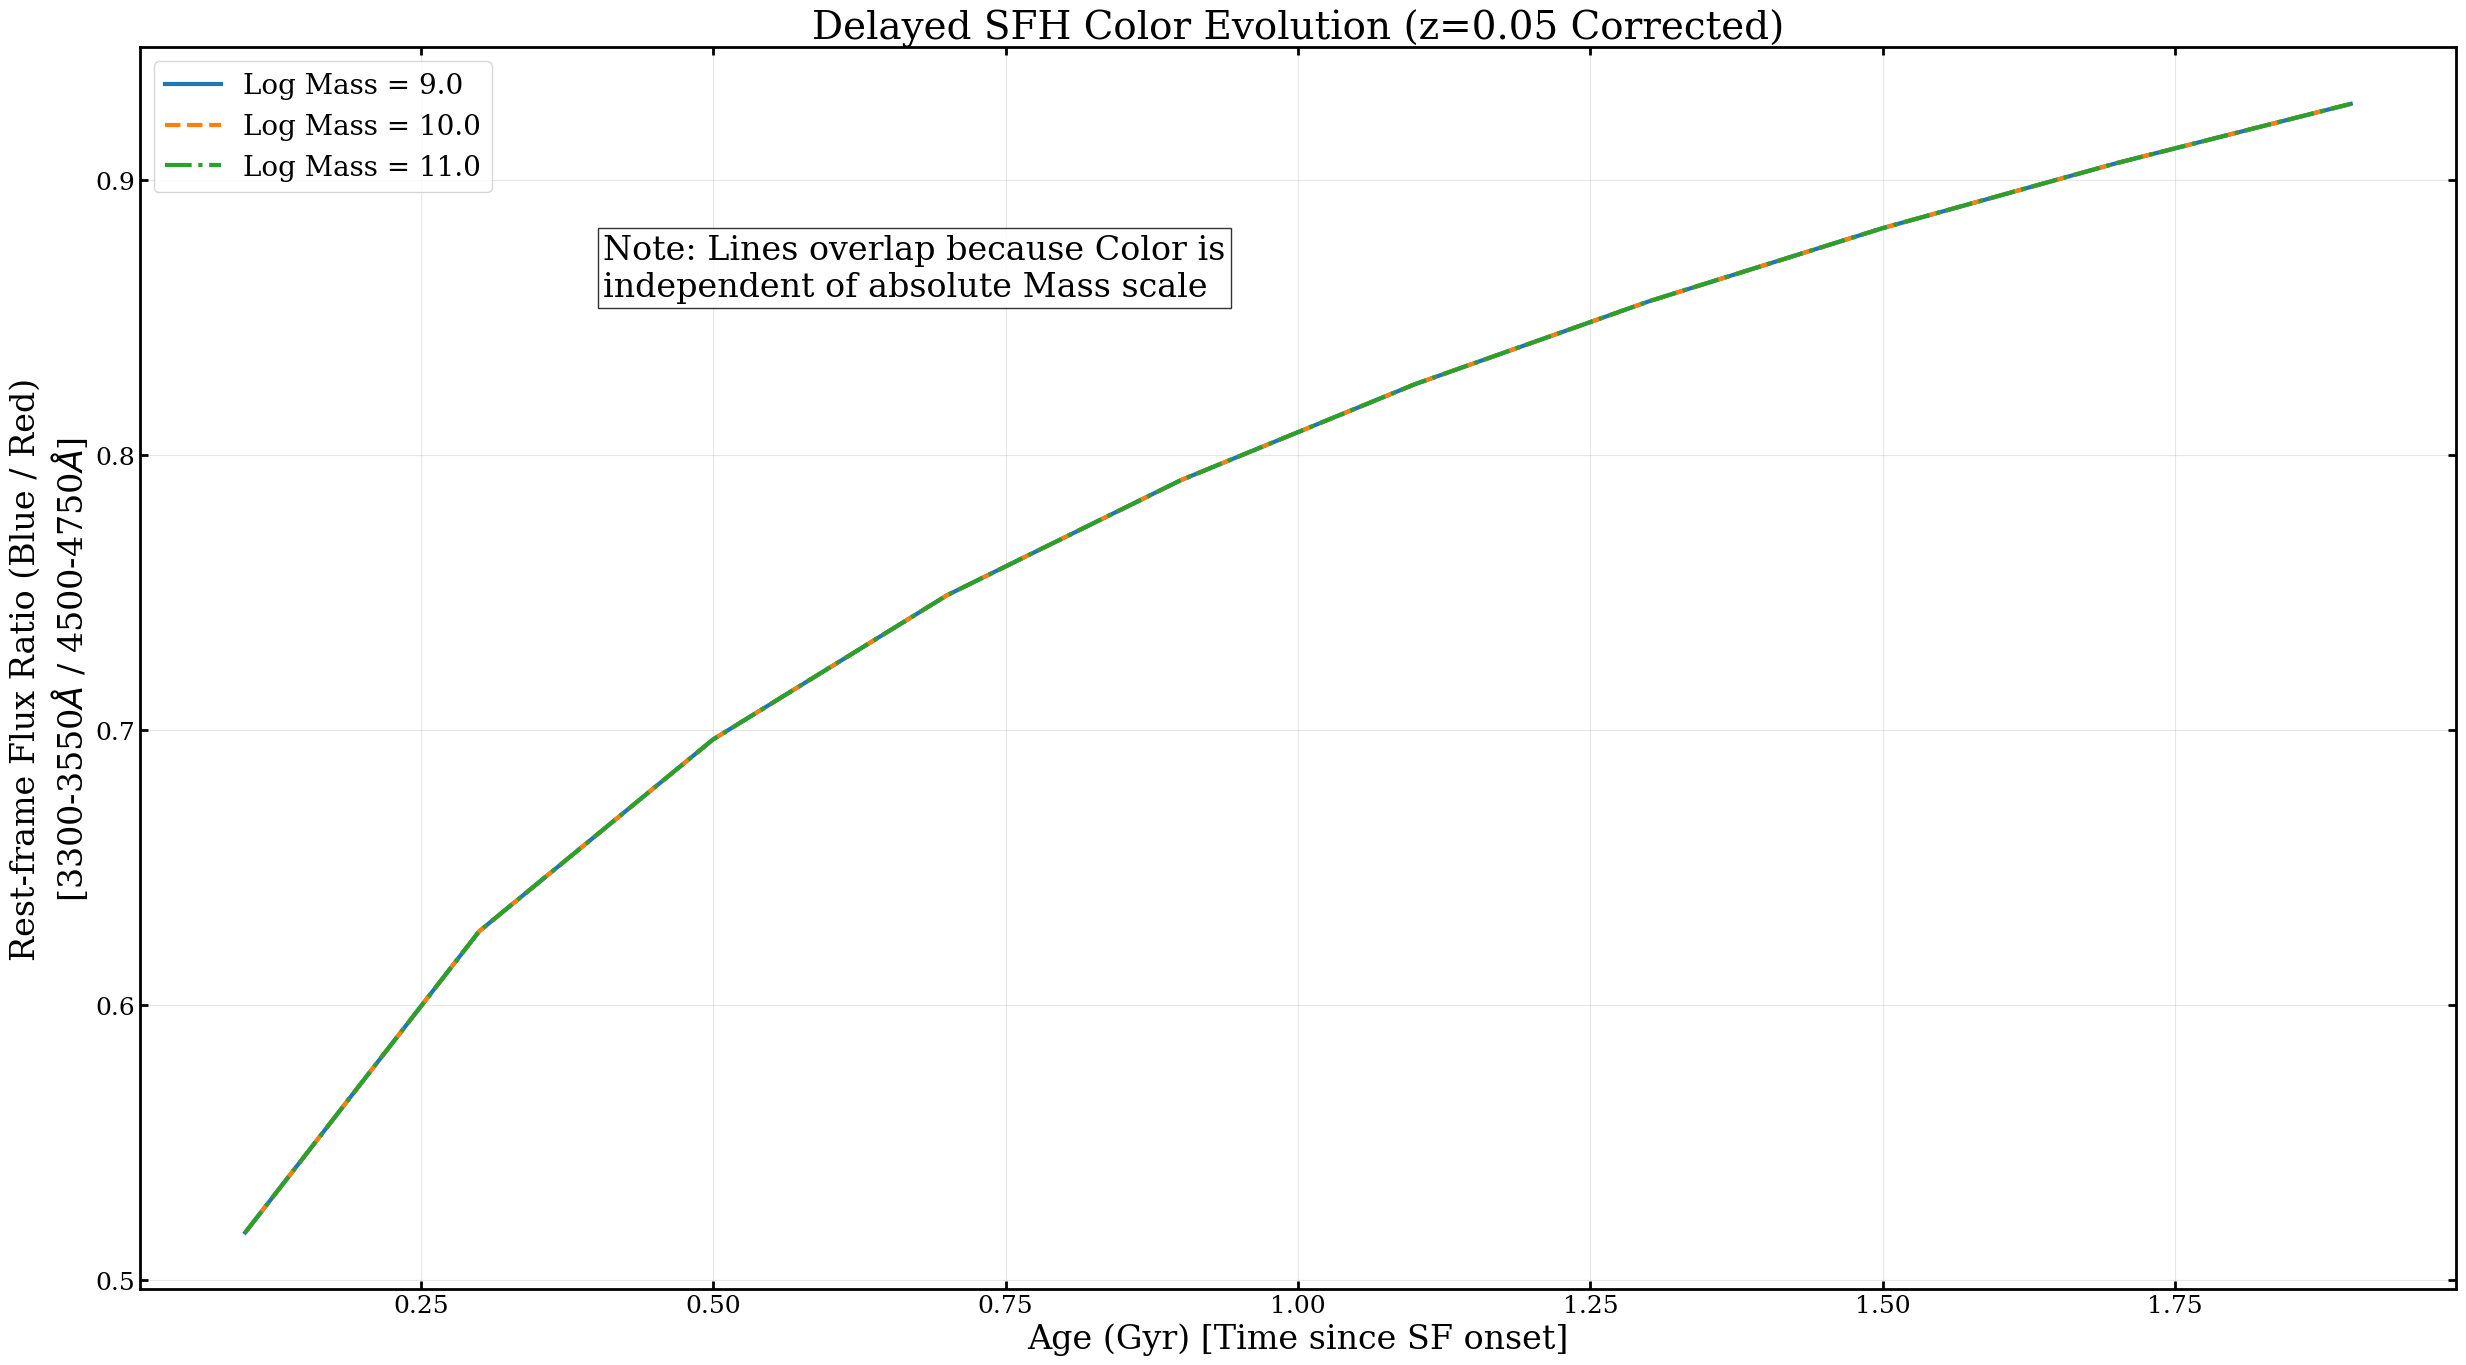

In [14]:
# 我们选择几个不同的总质量 (Log10 Mass) 来验证颜色比值是否只与形状有关，而与绝对亮度无关
# 这代替了之前的 SFR list，因为 Delayed 模型的 SFR 是随时间变化的
mass_list = [9.0, 10.0, 11.0]

# 设定红移
z = 0.05

# 基础模型配置
delayed_sfh = {}
delayed_sfh["tau"] = 2.0           # Decay timescale in Gyr
delayed_sfh["metallicity"] = 1.0   # Solar metallicity
# massformed 和 age 将在循环中动态更新

nebular = {}
nebular["logU"] = -2.5

model_components = {}
model_components["redshift"] = z
model_components["delayed"] = delayed_sfh
model_components["nebular"] = nebular

# --- 2. 准备循环 ---
# Delayed 模型通常演化时间较长，我们把年龄范围设为 0.1 到 5 Gyr
age_list = np.arange(0.1, 2.1, 0.2)

# 定义静止帧下的波长区间 (Rest-frame wavelengths)
b_left, b_right = 3300, 3550
r_left, r_right = 4500, 4750

# 绘图设置
plt.figure(figsize=(25, 14)) # 调整一下尺寸，不需要太大
linestyles = ['-', '--', '-.', ':']

print("正在计算 Delayed 模型演化...")

for i, target_mass in enumerate(mass_list):

    ratios = [] # 存储比值

    for age in tqdm(age_list, desc=f"LogMass = {target_mass}", leave=False):

        # 更新模型参数
        model_components["delayed"]["age"] = age # Time since star formation started
        model_components["delayed"]["massformed"] = target_mass

        # 生成模型 (Bagpipes 输出的是观测帧光谱)
        # 我们稍微扩大波长范围以容纳红移
        model = pipes.model_galaxy(model_components, spec_wavs=np.arange(3000, 6000, 10))

        # --- 关键步骤：红移校准 (Calibration) ---
        # Bagpipes 输出: model.spectrum[:, 0] 是观测波长 (1+z)*lambda_rest
        # Bagpipes 输出: model.spectrum[:, 1] 是观测通量

        # 1. 将波长转回静止帧 (Rest Frame)
        wave_rest = model.spectrum[:, 0] / (1 + z)

        # 2. 将通量转回静止帧 (为了保持积分比值物理意义，其实不做这一步比值也不变，但为了物理严谨)
        # F_rest = F_obs * (1+z)
        flux_rest = model.spectrum[:, 1] * (1 + z)


        # --- 计算积分 (注意：现在对 wave_rest 和 flux_rest 操作) ---

        # Blue Integral
        mask_b = (wave_rest >= b_left) & (wave_rest <= b_right)
        flux_b = flux_rest[mask_b]
        wave_b = wave_rest[mask_b]

        fluxsum = 0
        wavesum = 0

        # 使用 j 作为循环变量，避免覆盖外层的 i
        for j in range(len(flux_b)):
            left = wave_b[j]
            right = wave_b[j+1] if j+1 < len(flux_b) else wave_b[j] + 10 # +10是spec_wavs的step

            fluxsum += flux_b[j] * (right - left)
            wavesum += right - left

        int_b = fluxsum / wavesum if wavesum > 0 else 1e-99

        # Red Integral
        mask_r = (wave_rest >= r_left) & (wave_rest <= r_right)
        flux_r = flux_rest[mask_r]
        wave_r = wave_rest[mask_r]

        fluxsum = 0
        wavesum = 0

        for j in range(len(flux_r)):
            left = wave_r[j]
            right = wave_r[j+1] if j+1 < len(flux_r) else wave_r[j] + 10

            fluxsum += flux_r[j] * (right - left)
            wavesum += right - left

        int_r = fluxsum / wavesum if wavesum > 0 else 1e-99

        ratios.append(int_r / int_b)

    print(f"LogMass = {target_mass} 完成。")

    # 绘图
    plt.plot(age_list, ratios,
             label=f"Log Mass = {target_mass}",
             linestyle=linestyles[i % len(linestyles)],
             linewidth=3.0) # 固定线宽或使用安全的计算方式

plt.xlabel("Age (Gyr) [Time since SF onset]")
plt.ylabel(f"Rest-frame Flux Ratio (Blue / Red)\n[{b_left}-{b_right}$\AA$ / {r_left}-{r_right}$\AA$]")
plt.title(f"Delayed SFH Color Evolution (z={z} Corrected)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.text(0.2, 0.8, "Note: Lines overlap because Color is\nindependent of absolute Mass scale",
         transform=plt.gca().transAxes, fontsize=24,
         bbox=dict(facecolor='white', alpha=0.8))
plt.savefig("bagpipes_delayed_mass_color_ratio.pdf")
plt.show()

In [39]:
# --- 1. 参数设置 ---
age_list = [0.01, 0.1, 0.5, 1.0, 2.0]
z = 0.01

# Delayed 模型参数
delayed_sfh = {}
delayed_sfh["tau"] = 0.5         # 0.5 Gyr 时 SFR 达到峰值
delayed_sfh["massformed"] = 10.5 # Log10 总恒星质量 (固定质量，观察演化)
delayed_sfh["metallicity"] = 0.2

nebular = {}
nebular["logU"] = -2.5

model_components = {}
model_components["redshift"] = z
model_components["delayed"] = delayed_sfh
model_components["nebular"] = nebular

# --- 2. 循环计算 ---
waves_list = []
flux_list = []

print("正在计算 Delayed SFH 模型...")

for age in tqdm(age_list):
    # 1. 更新年龄
    model_components["delayed"]["age"] = age

    # 2. 生成模型
    model = pipes.model_galaxy(model_components, spec_wavs=np.arange(500, 8000, 5))

    # 3. 红移校准 (Observed -> Rest Frame)
    wave = model.spectrum[:, 0] / (1 + z)
    flux = model.spectrum[:, 1] * (1 + z)

    waves_list.append(wave)
    flux_list.append(flux)

# 将列表转换为 numpy 数组
waves_arrays = np.column_stack(waves_list)
flux_arrays = np.column_stack(flux_list)



正在计算 Delayed SFH 模型...


100%|██████████| 5/5 [00:06<00:00,  1.38s/it]


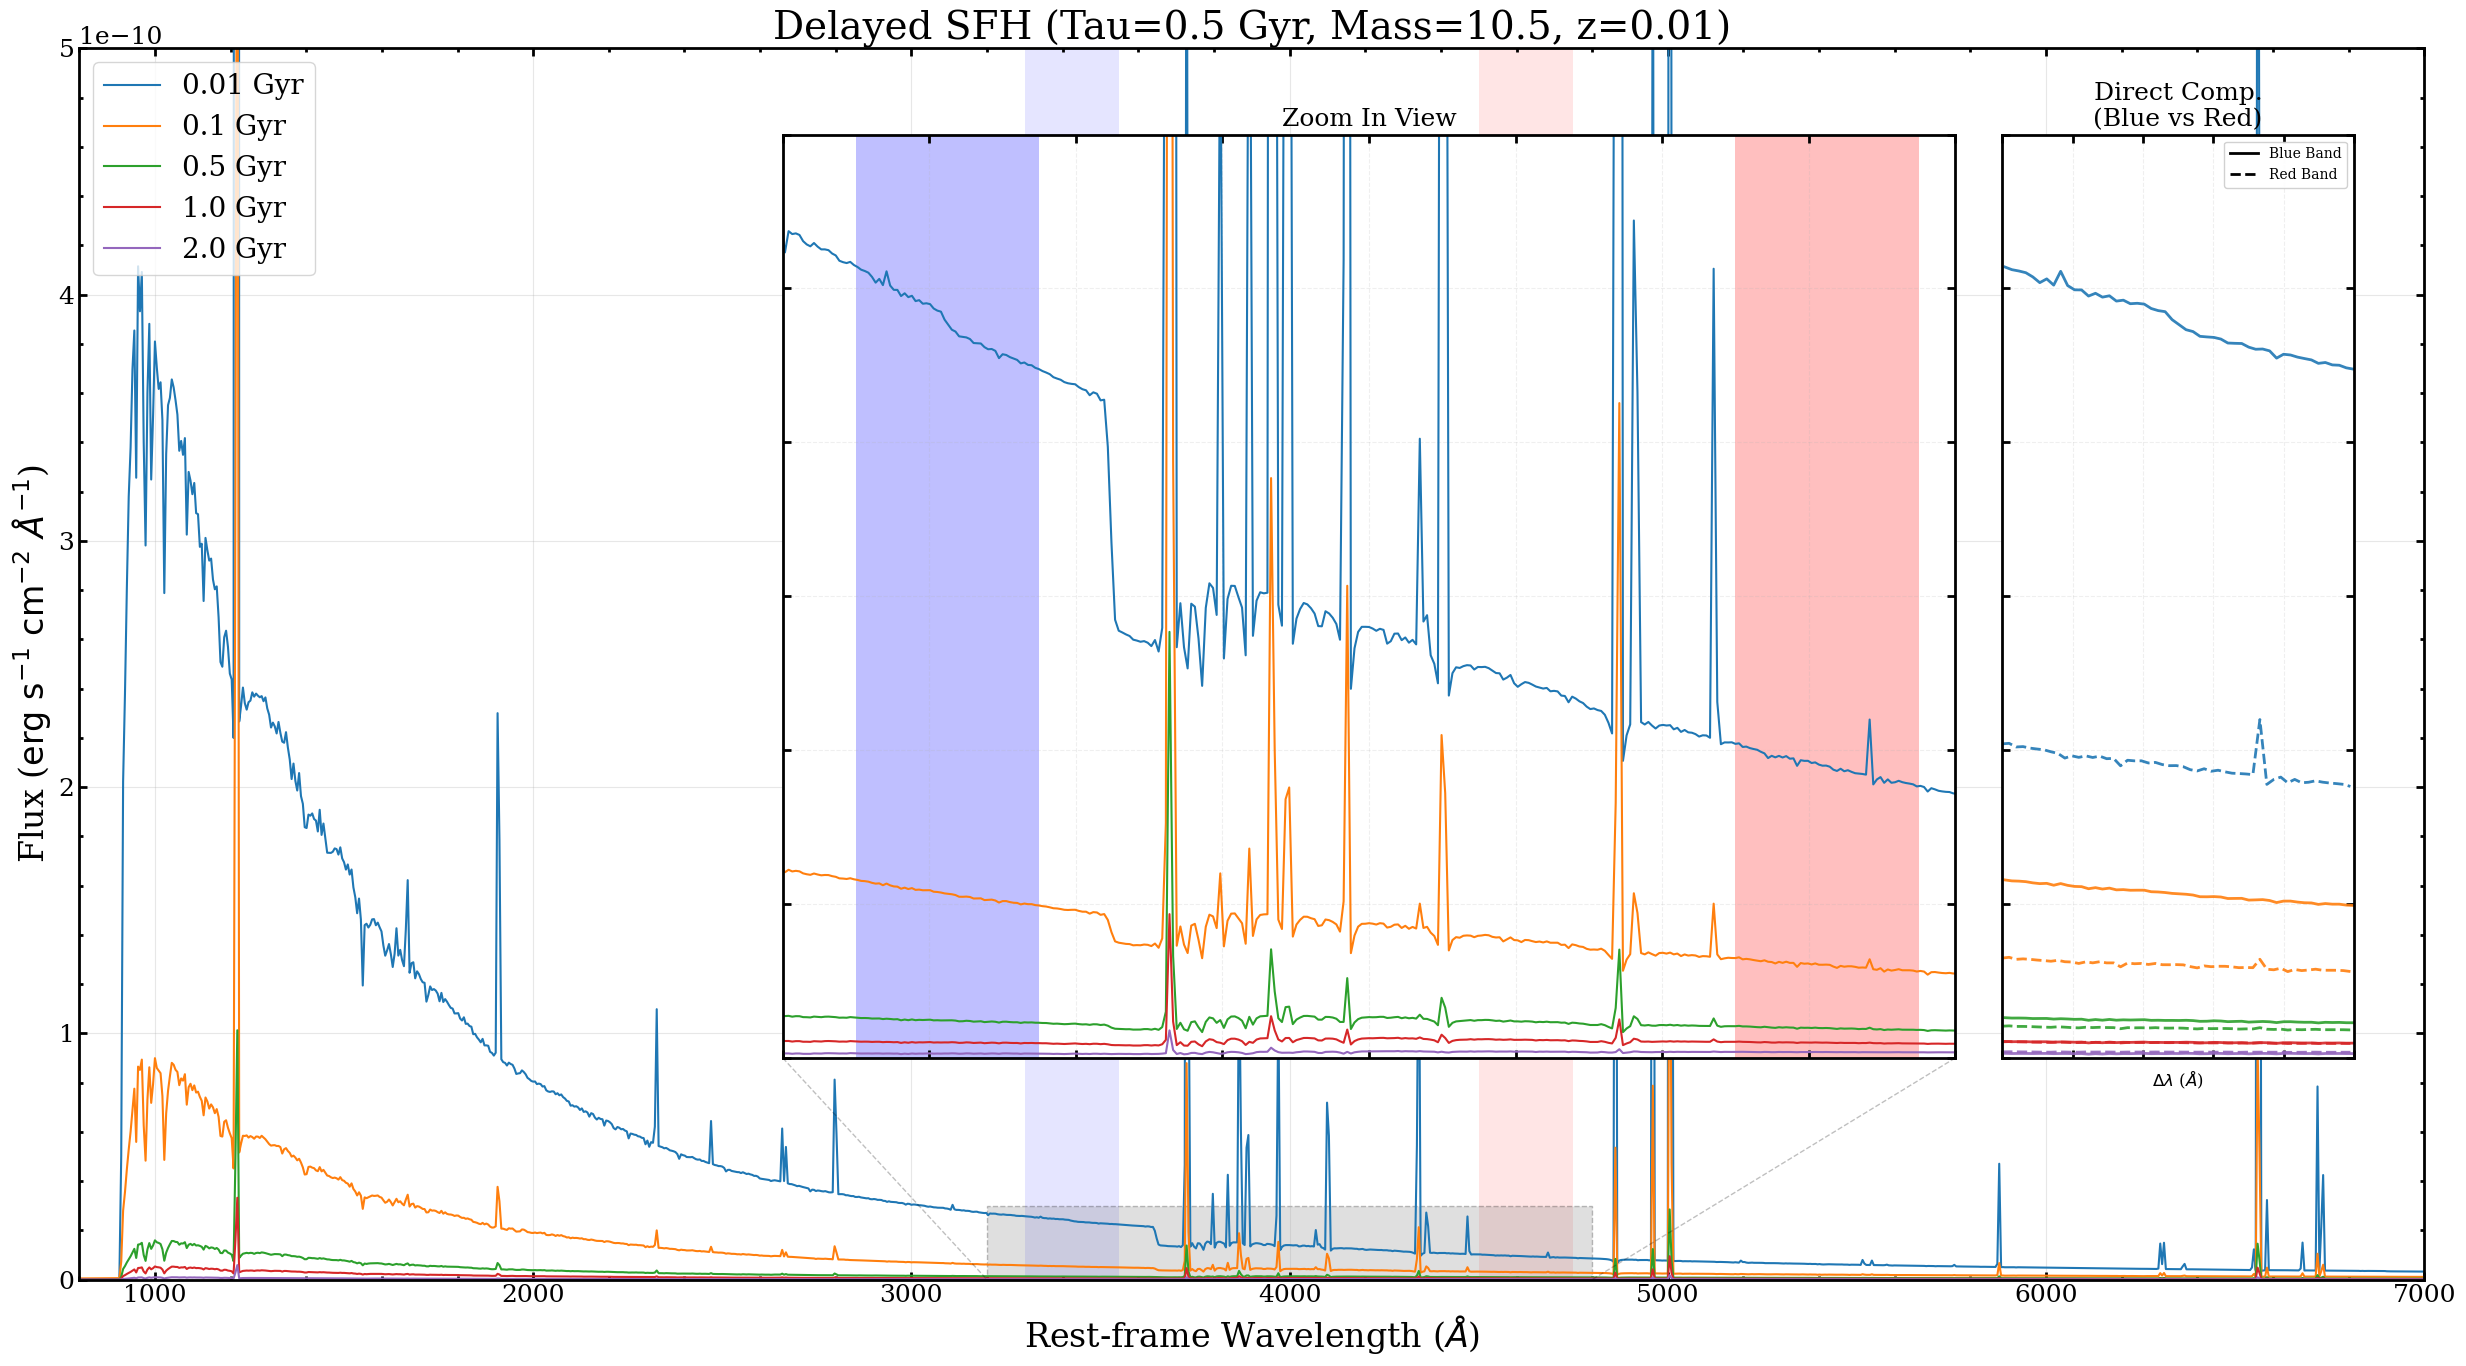

In [40]:

# --- 3. 绘图 (严格保持原尺寸和字体) ---
fig, ax = plt.subplots(figsize=(25, 14))

# 自动调整 Y 轴上限，因为 Delayed 模型的亮度变化比 Constant 大
# 我们取所有数据的最大值稍微放大一点，或者保持你之前的固定值
# 为了视觉效果，这里我稍微动态调整一下 ylim_main，但保持你代码的结构
max_flux = np.max(flux_arrays)
ylim_main = 5e-10
if ylim_main < 1e-12: ylim_main = 1.2e-12 # 保持底线以免太低

for i in range(len(age_list)):
    ax.plot(waves_arrays[:,i], flux_arrays[:,i], label=f"{age_list[i]} Gyr")

ax.set_xlabel(r"Rest-frame Wavelength ($\AA$)")
ax.set_ylabel("Flux ($\\text{erg}\ \\text{s}^{-1}\ \\text{cm}^{-2}\ \\AA^{-1}$)")
ax.set_title(f"Delayed SFH (Tau=0.5 Gyr, Mass=10.5, z={z})")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, ylim_main)
ax.set_xlim(800, 7000)

# 矩形区域 (高度随 ylim_main 调整)
rect_blue = patches.Rectangle((3300, 0), 250, ylim_main, facecolor='blue', alpha=0.1, edgecolor='none')
rect_red  = patches.Rectangle((4500, 0), 250, ylim_main, facecolor='red', alpha=0.1, edgecolor='none')
ax.add_patch(rect_blue)
ax.add_patch(rect_red)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# --- 插图 1: Zoom In ---
axins_zoom = ax.inset_axes([0.3, 0.18, 0.5, 0.75])
axins_comp = ax.inset_axes([0.82, 0.18, 0.15, 0.75])

# 插图 Y 轴上限
ylim_inset = 3e-11

for i in range(len(age_list)):
    axins_zoom.plot(waves_arrays[:,i], flux_arrays[:,i])

axins_zoom.fill_between([3300, 3550], 0, ylim_inset, facecolor='blue', alpha=0.25)
axins_zoom.fill_between([4500, 4750], 0, ylim_inset, facecolor='red', alpha=0.25)

axins_zoom.set_xlim(3200, 4800)
axins_zoom.set_ylim(0, ylim_inset)
axins_zoom.tick_params(axis='both', labelsize=12)
axins_zoom.set_title("Zoom In View", fontsize=18)
axins_zoom.grid(True, alpha=0.2, linestyle='--')
axins_zoom.set_xticklabels([])
axins_zoom.set_yticklabels([])

mark_inset(ax, axins_zoom, loc1=3, loc2=4, fc="gray", alpha=0.25, ec="k", lw=1, linestyle='--')


# --- 插图 2: Direct Comparison ---
blue_start = 3300
red_start = 4500
span = 250

for i in range(len(age_list)):
    # 获取颜色
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]

    w = waves_arrays[:,i]
    f = flux_arrays[:,i]

    # --- 蓝色部分 (实线) ---
    mask_b = (w >= blue_start) & (w <= blue_start + span)
    axins_comp.plot(w[mask_b] - blue_start, f[mask_b],
                    color=color, linestyle='-', linewidth=2, alpha=0.9)

    # --- 红色部分 (虚线) ---
    mask_r = (w >= red_start) & (w <= red_start + span)
    axins_comp.plot(w[mask_r] - red_start, f[mask_r],
                    color=color, linestyle='--', linewidth=2, alpha=0.9)

# 设置范围和样式
axins_comp.set_xlim(0, span)
axins_comp.set_ylim(0, ylim_inset)
axins_comp.set_title("Direct Comp.\n(Blue vs Red)", fontsize=18)
axins_comp.set_xlabel(r"$\Delta \lambda$ ($\AA$)", fontsize=12)

axins_comp.set_yticklabels([])
axins_comp.tick_params(axis='x', labelsize=12)
axins_comp.grid(True, alpha=0.2, linestyle='--')
axins_comp.set_xticklabels([])
axins_comp.set_yticklabels([])

# 图例
legend_elements = [Line2D([0], [0], color='k', lw=2, label='Blue Band', linestyle='-'),
                   Line2D([0], [0], color='k', lw=2, label='Red Band', linestyle='--')]
axins_comp.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig("bagpipes_delayed_SFH_restframe.pdf")
plt.show()

正在验证比值与规模 (Mass/SFR) 的无关性...


LogMass = 8.0:  10%|█         | 1/10 [00:01<00:10,  1.12s/it]/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/bagpipes/models/star_formation_history.py:131: RuntimeWarning: divide by zero encountered in log10
  self.ssfr = np.log10(self.sfr) - self.stellar_mass
/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/bagpipes/models/star_formation_history.py:132: RuntimeWarning: divide by zero encountered in log10
  self.nsfr = np.log10(self.sfr*self.age_of_universe) - self.formed_mass


Log Mass = 8.0 完成。


Log Mass = 10.0 完成。


Log Mass = 12.0 完成。


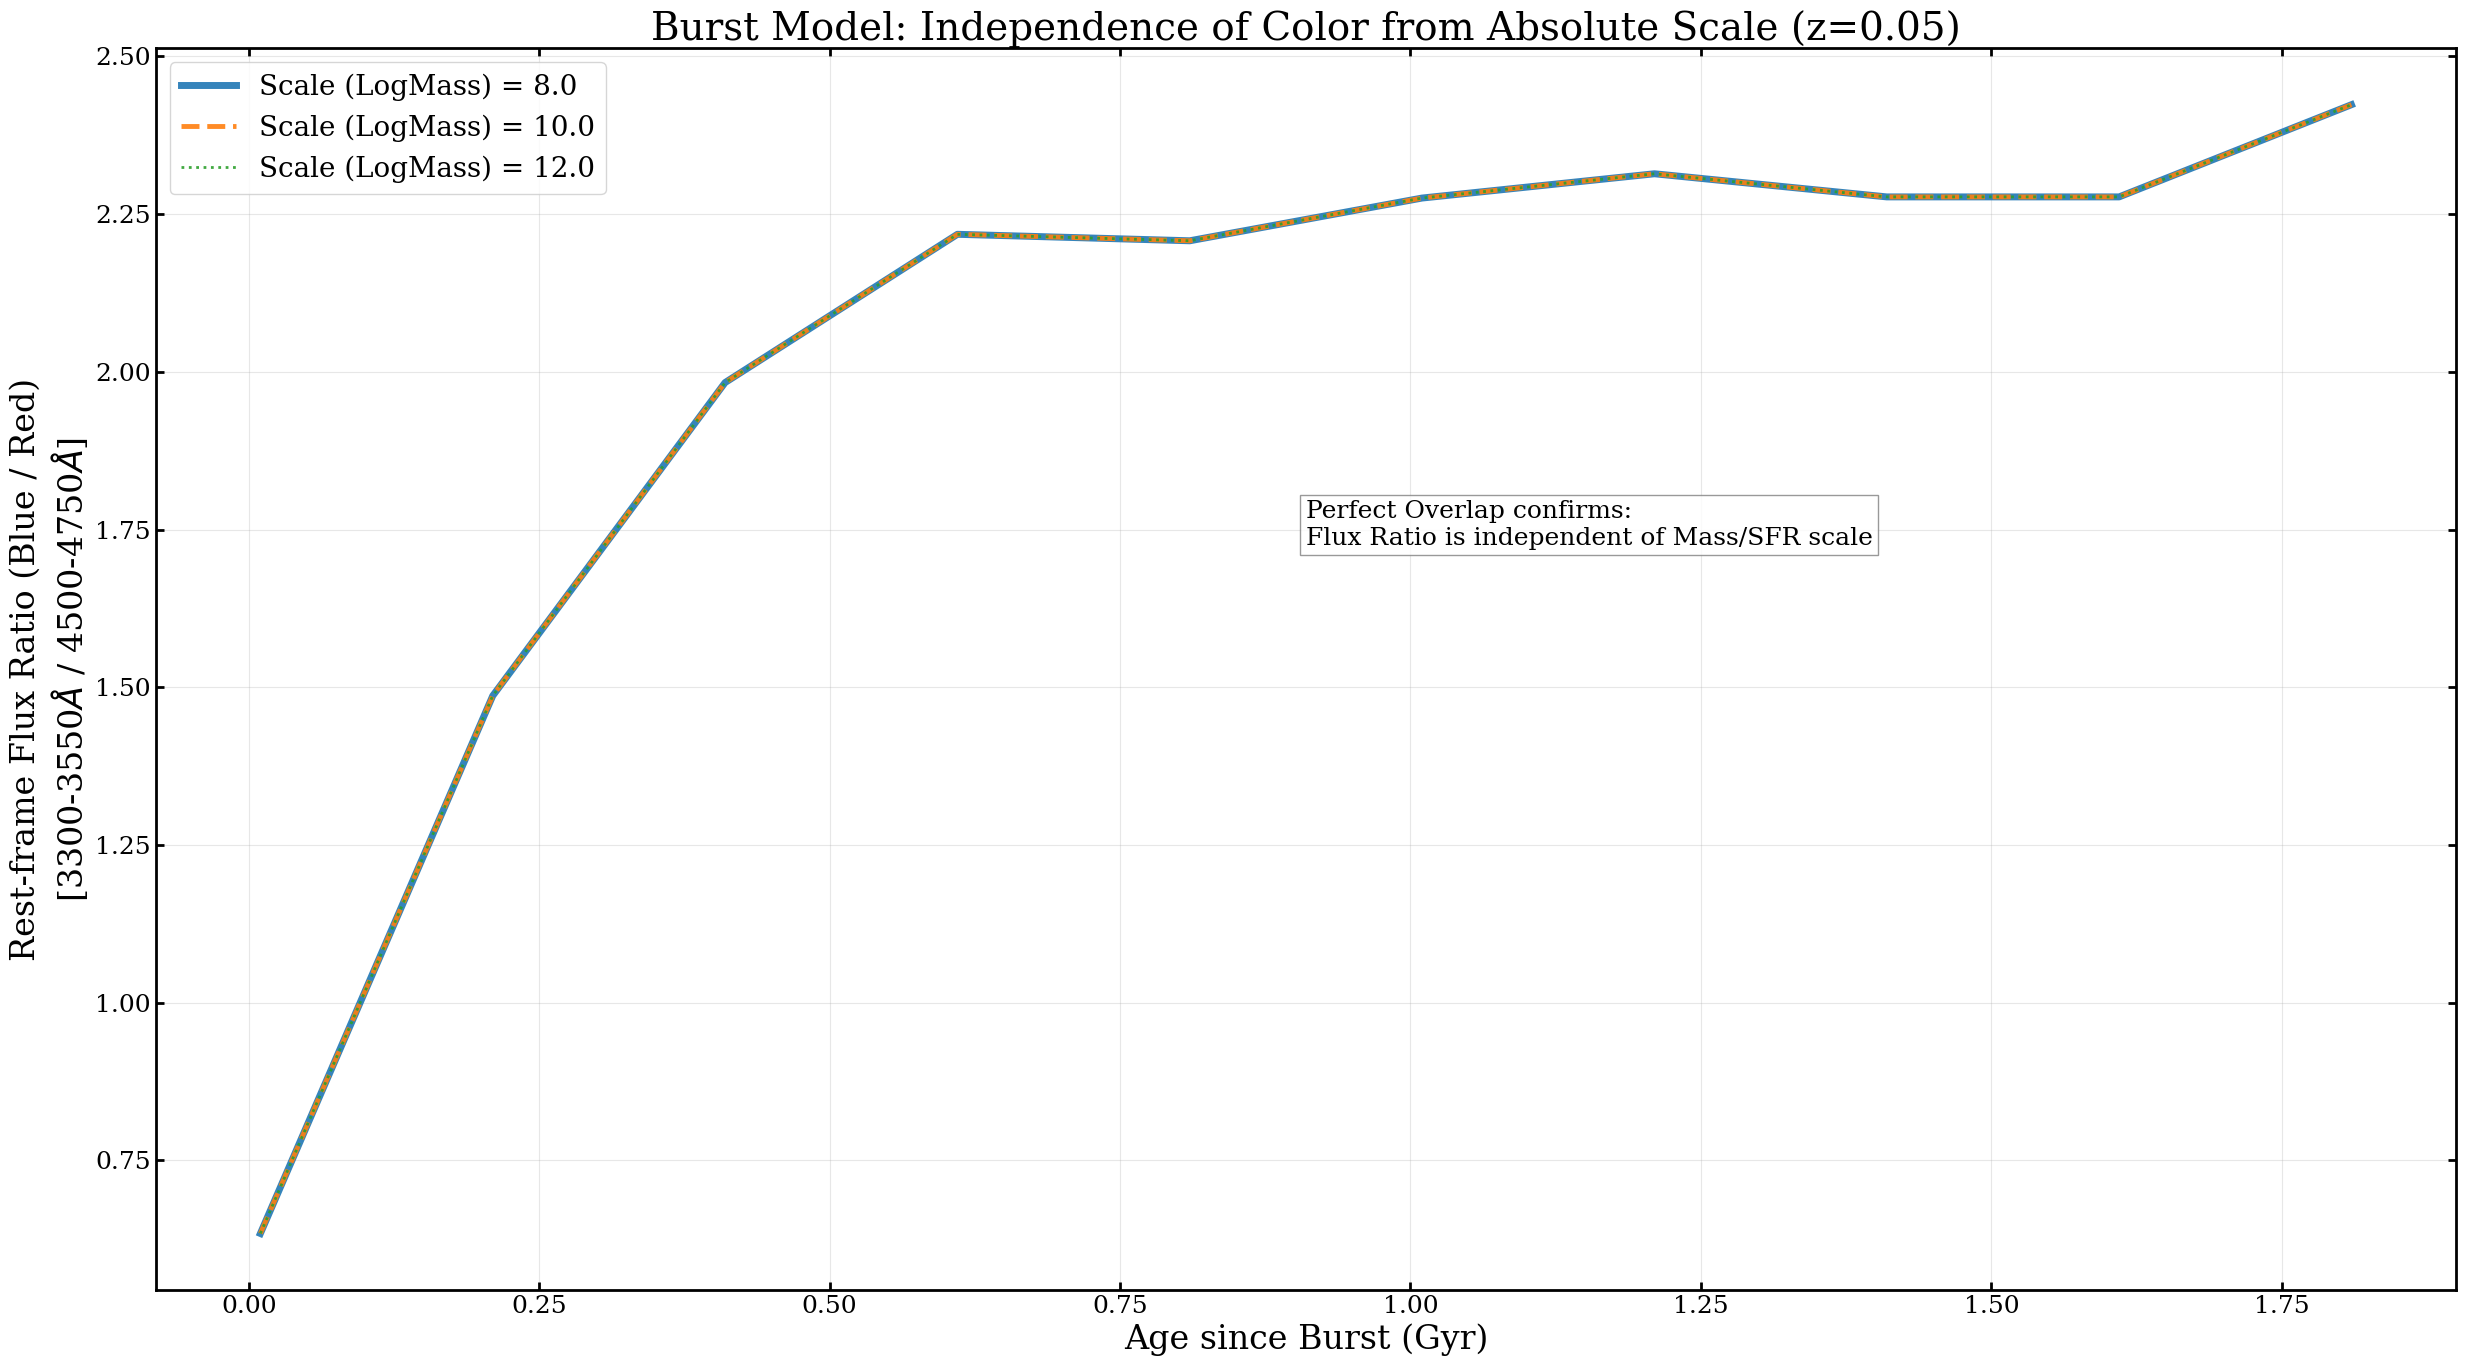

In [15]:

scale_list = [8.0, 10.0, 12.0] # Log10 Total Mass Formed

# 基础模型配置
burst_sfh = {}
burst_sfh["metallicity"] = 1.0   # Solar metallicity
# massformed 和 age 将在循环中更新

nebular = {}
nebular["logU"] = -3.0           # 保持 logU = -3.0

model_components = {}
model_components["redshift"] = 0.05 # 保持 z=0.05
model_components["burst"] = burst_sfh
model_components["nebular"] = nebular

# --- 2. 准备循环 ---
age_list = np.arange(0.01, 2.01, 0.2) # 从 10 Myr 到 2 Gyr

# 定义静止帧下的波长区间 (Rest-frame)
b_left, b_right = 3300, 3550
r_left, r_right = 4500, 4750

# 绘图设置
plt.figure(figsize=(25,14))
# 使用不同的线型，以便如果它们重合，我们能看出来
linestyles = ['-', '--', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

print("正在验证比值与规模 (Mass/SFR) 的无关性...")

for i, target_mass in enumerate(scale_list):

    ratios = [] # 存储比值

    # 更新恒星形成总质量 (规模)
    model_components["burst"]["massformed"] = target_mass

    for age in tqdm(age_list, desc=f"LogMass = {target_mass}", leave=False):

        # 更新年龄 (自爆发以来的时间)
        model_components["burst"]["age"] = age

        # 生成模型 (Bagpipes 输出的是观测帧光谱)
        model = pipes.model_galaxy(model_components, spec_wavs=np.arange(2000, 7000, 20))

        # --- 红移校准 (De-redshifting) ---
        z = model_components["redshift"]
        # 1. 波长转回静止帧
        wave_rest = model.spectrum[:, 0] / (1 + z)
        # 2. 通量转回静止帧 (保持物理一致)
        flux_rest = model.spectrum[:, 1] * (1 + z)


        # --- 积分计算 (使用 rest-frame 数据) ---

        # Blue Integral
        mask_b = (wave_rest >= b_left) & (wave_rest <= b_right)
        flux_b = flux_rest[mask_b]
        wave_b = wave_rest[mask_b]

        fluxsum = 0
        wavesum = 0

        # 使用 j 作为循环变量，避免覆盖外层的 i !!!
        for j in range(len(flux_b)):
            left = wave_b[j]
            right = wave_b[j+1] if j+1 < len(flux_b) else wave_b[j] + 20
            fluxsum += flux_b[j] * (right - left)
            wavesum += right - left
        int_b = fluxsum / wavesum if wavesum > 0 else 1e-99


        # Red Integral
        mask_r = (wave_rest >= r_left) & (wave_rest <= r_right)
        flux_r = flux_rest[mask_r]
        wave_r = wave_rest[mask_r]

        fluxsum = 0
        wavesum = 0

        # 使用 j 作为循环变量
        for j in range(len(flux_r)):
            left = wave_r[j]
            right = wave_r[j+1] if j+1 < len(flux_r) else wave_r[j] + 20
            fluxsum += flux_r[j] * (right - left)
            wavesum += right - left
        int_r = fluxsum / wavesum if wavesum > 0 else 1e-99

        ratios.append(int_r / int_b)

    print(f"Log Mass = {target_mass} 完成。")

    # 绘图：改变线宽，使得重合时能看到底下的线
    plt.plot(age_list, ratios,
             label=f"Scale (LogMass) = {target_mass}",
             linestyle=linestyles[i % len(linestyles)],
             color=colors[i % len(colors)],
             linewidth=5.0 - i*1.5, # 粗细不同，方便观察重叠
             alpha=0.9)

plt.xlabel("Age since Burst (Gyr)")
plt.ylabel(f"Rest-frame Flux Ratio (Blue / Red)\n[{b_left}-{b_right}$\AA$ / {r_left}-{r_right}$\AA$]")
plt.title(f"Burst Model: Independence of Color from Absolute Scale (z={z})")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 添加说明文本
plt.text(0.5, 0.6, "Perfect Overlap confirms:\nFlux Ratio is independent of Mass/SFR scale",
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.savefig("bagpipes_burst_scale_color_ratio.pdf")
plt.show()

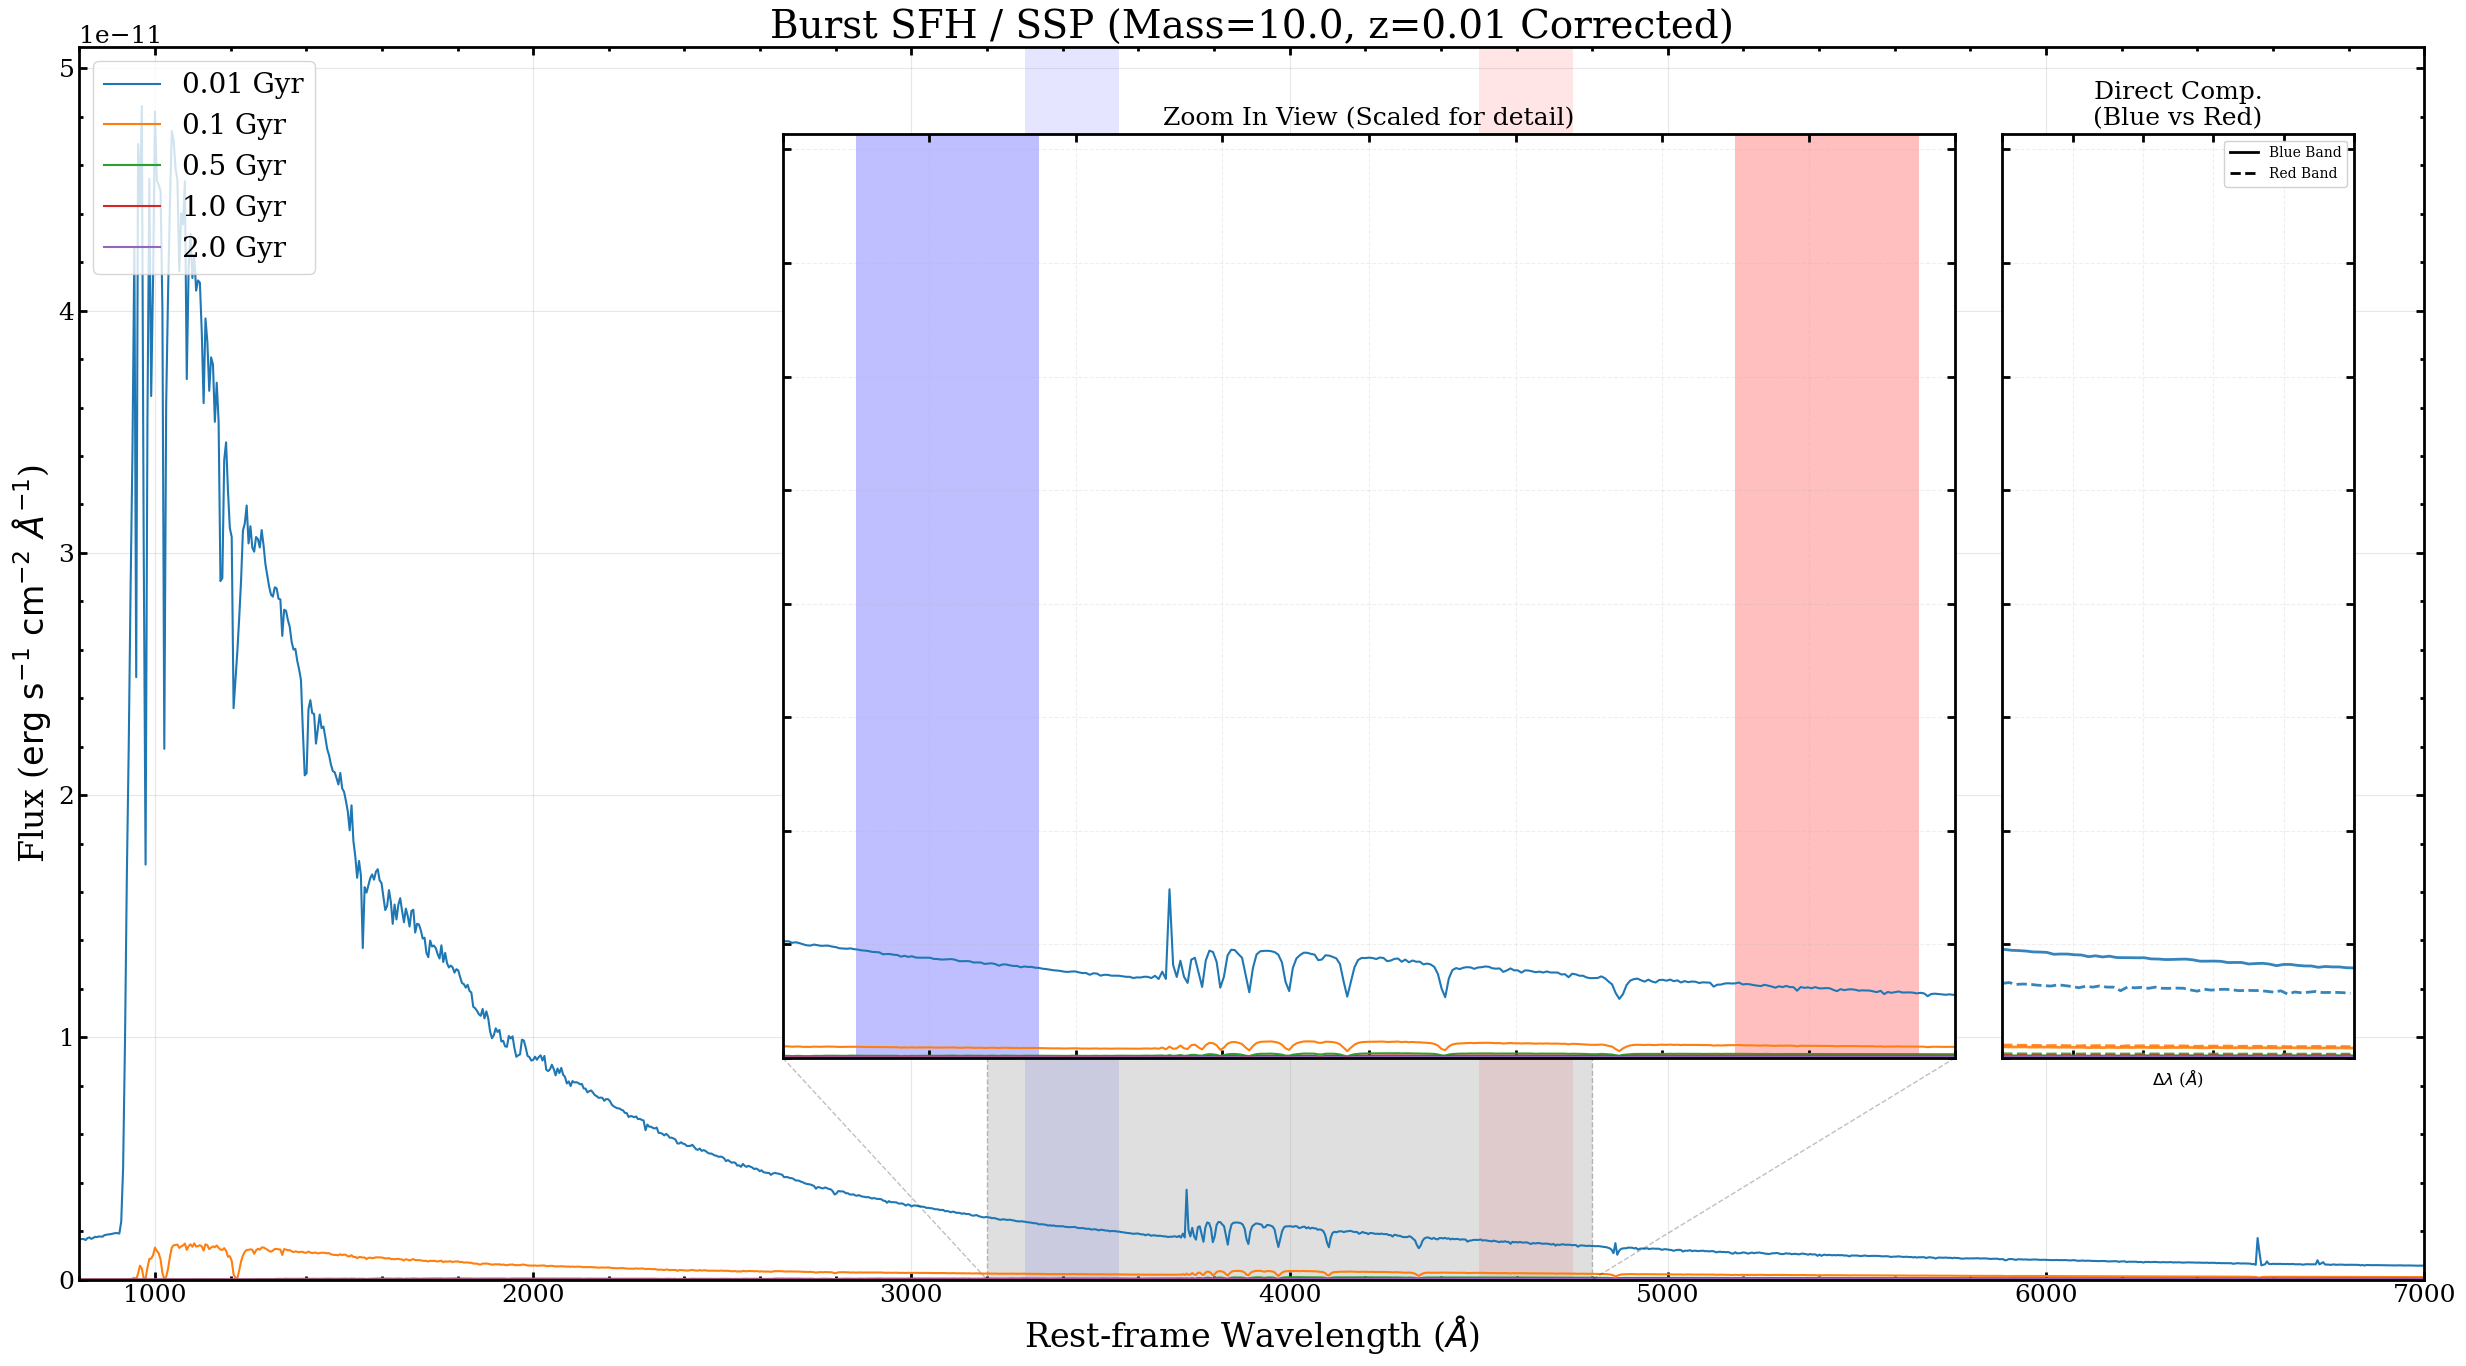

In [8]:
fig, ax = plt.subplots(figsize=(25, 14))

# 动态设置 Y 轴上限
# Burst 模型早期非常亮，为了兼顾展示，我们取最大值的 1.1 倍
# 注意：这会导致 1.0 Gyr 的线看起来非常接近 0，因为亮度跨度太大
max_flux = np.max(flux_arrays)
ylim_main = max_flux * 1.05

for i in range(len(age_list)):
    ax.plot(waves_arrays[:,i], flux_arrays[:,i], label=f"{age_list[i]} Gyr")

ax.set_xlabel(r"Rest-frame Wavelength ($\AA$)")
ax.set_ylabel("Flux ($\\text{erg}\ \\text{s}^{-1}\ \\text{cm}^{-2}\ \\AA^{-1}$)")
ax.set_title(f"Burst SFH / SSP (Mass=10.0, z={z} Corrected)")
ax.legend(loc='upper left') # 改到右上，因为 Burst 左侧通常很高
ax.grid(True, alpha=0.3)
ax.set_ylim(0, ylim_main)
ax.set_xlim(800, 7000)

# 矩形区域
rect_blue = patches.Rectangle((3300, 0), 250, ylim_main, facecolor='blue', alpha=0.1, edgecolor='none')
rect_red  = patches.Rectangle((4500, 0), 250, ylim_main, facecolor='red', alpha=0.1, edgecolor='none')
ax.add_patch(rect_blue)
ax.add_patch(rect_red)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# --- 插图 1: Zoom In ---
axins_zoom = ax.inset_axes([0.3, 0.18, 0.5, 0.75])
axins_comp = ax.inset_axes([0.82, 0.18, 0.15, 0.75])

# 插图 Y 轴上限：
# 对于 Burst，为了能看清较暗的线，我们将插图的 limit 设为最大值的 1/3 左右，
# 这样虽然年轻的线会爆表（切断），但能看清年老线的斜率。
ylim_inset = (ylim_main )* 0.4

for i in range(len(age_list)):
    axins_zoom.plot(waves_arrays[:,i], flux_arrays[:,i])

axins_zoom.fill_between([3300, 3550], 0, ylim_inset, facecolor='blue', alpha=0.25)
axins_zoom.fill_between([4500, 4750], 0, ylim_inset, facecolor='red', alpha=0.25)

axins_zoom.set_xlim(3200, 4800)
axins_zoom.set_ylim(0, ylim_inset) if ylim_inset > 0 else axins_zoom.set_ylim(ylim_inset, 0)
axins_zoom.tick_params(axis='both', labelsize=12)
axins_zoom.set_title("Zoom In View (Scaled for detail)", fontsize=18)
axins_zoom.grid(True, alpha=0.2, linestyle='--')
axins_zoom.set_xticklabels([])
axins_zoom.set_yticklabels([])

mark_inset(ax, axins_zoom, loc1=3, loc2=4, fc="gray", alpha=0.25, ec="k", lw=1, linestyle='--')


# --- 插图 2: Direct Comparison ---
blue_start = 3300
red_start = 4500
span = 250

for i in range(len(age_list)):
    # 获取颜色
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]

    w = waves_arrays[:,i]
    f = flux_arrays[:,i]

    # --- 蓝色部分 (实线) ---
    mask_b = (w >= blue_start) & (w <= blue_start + span)
    axins_comp.plot(w[mask_b] - blue_start, f[mask_b],
                    color=color, linestyle='-', linewidth=2, alpha=0.9)

    # --- 红色部分 (虚线) ---
    mask_r = (w >= red_start) & (w <= red_start + span)
    axins_comp.plot(w[mask_r] - red_start, f[mask_r],
                    color=color, linestyle='--', linewidth=2, alpha=0.9)

# 设置范围和样式
axins_comp.set_xlim(0, span)
axins_comp.set_ylim(0, ylim_inset)
axins_comp.set_title("Direct Comp.\n(Blue vs Red)", fontsize=18)
axins_comp.set_xlabel(r"$\Delta \lambda$ ($\AA$)", fontsize=12)

axins_comp.set_yticklabels([])
axins_comp.tick_params(axis='x', labelsize=12)
axins_comp.grid(True, alpha=0.2, linestyle='--')
axins_comp.set_xticklabels([])
axins_comp.set_yticklabels([])

# 图例
legend_elements = [Line2D([0], [0], color='k', lw=2, label='Blue Band', linestyle='-'),
                   Line2D([0], [0], color='k', lw=2, label='Red Band', linestyle='--')]
axins_comp.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig("bagpipes_burst_SFH_restframe.pdf")
plt.show()

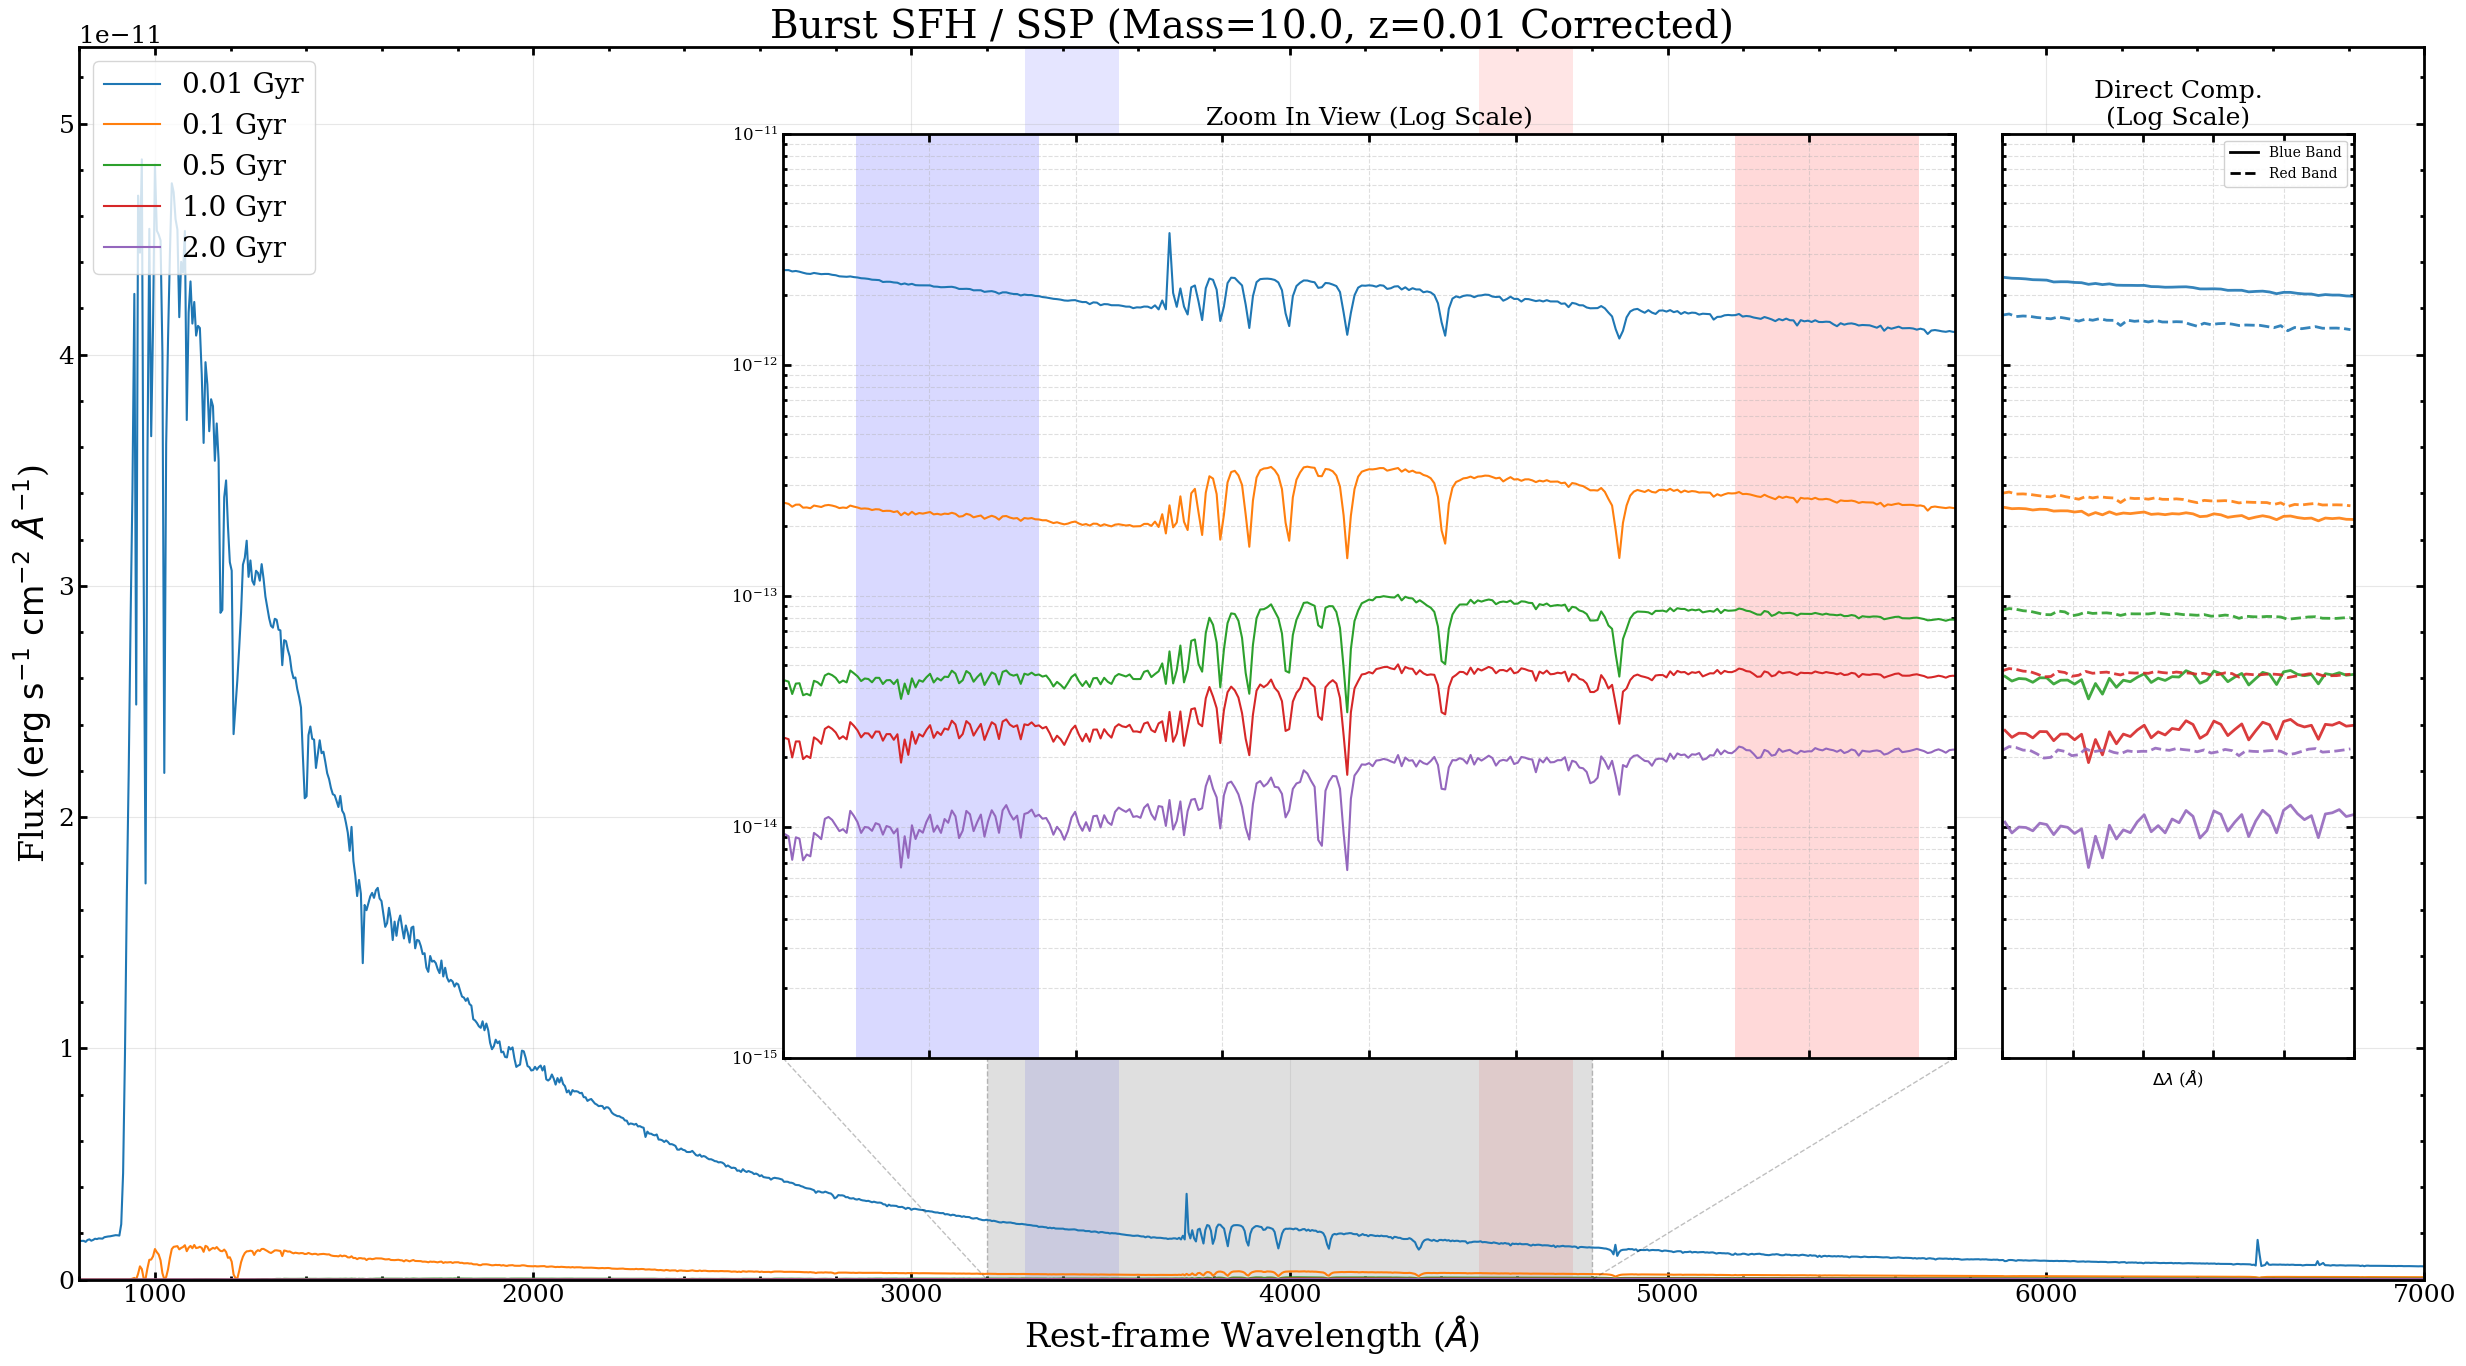

In [9]:
fig, ax = plt.subplots(figsize=(25, 14))

# 计算极值以便设置 Log 坐标的范围
max_flux = np.max(flux_arrays)
# 找到大于0的最小值，作为 Log 坐标的底
min_valid_flux = np.min(flux_arrays[flux_arrays > 0])
ymin_log = 1e-15#稍微留点余量
ymax_log = 1e-11     #稍微留点余量

# 主图保持线性 (Linear) 以展示绝对强度的剧烈下降
for i in range(len(age_list)):
    ax.plot(waves_arrays[:,i], flux_arrays[:,i], label=f"{age_list[i]} Gyr")

ax.set_xlabel(r"Rest-frame Wavelength ($\AA$)")
ax.set_ylabel("Flux ($\\text{erg}\ \\text{s}^{-1}\ \\text{cm}^{-2}\ \\AA^{-1}$)")
ax.set_title(f"Burst SFH / SSP (Mass=10.0, z={z} Corrected)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max_flux * 1.1)
ax.set_xlim(800, 7000)

# 矩形区域
rect_blue = patches.Rectangle((3300, 0), 250, max_flux * 1.1, facecolor='blue', alpha=0.1, edgecolor='none')
rect_red  = patches.Rectangle((4500, 0), 250, max_flux * 1.1, facecolor='red', alpha=0.1, edgecolor='none')
ax.add_patch(rect_blue)
ax.add_patch(rect_red)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# --- 插图 1: Zoom In (使用 Log Scale) ---
axins_zoom = ax.inset_axes([0.3, 0.18, 0.5, 0.75])
axins_comp = ax.inset_axes([0.82, 0.18, 0.15, 0.75])

# 设置 Log 模式
axins_zoom.set_yscale("log")
axins_comp.set_yscale("log")

for i in range(len(age_list)):
    axins_zoom.plot(waves_arrays[:,i], flux_arrays[:,i])

# 在 Log 模式下，fill_between 的底部不能是 0，必须是一个正数
axins_zoom.fill_between([3300, 3550], ymin_log, ymax_log, facecolor='blue', alpha=0.15)
axins_zoom.fill_between([4500, 4750], ymin_log, ymax_log, facecolor='red', alpha=0.15)

axins_zoom.set_xlim(3200, 4800)
axins_zoom.set_ylim(ymin_log, ymax_log) # 设置 Log 的上下限

axins_zoom.tick_params(axis='both', labelsize=12)
axins_zoom.set_title("Zoom In View (Log Scale)", fontsize=18)
axins_zoom.grid(True, alpha=0.4, which="both", linestyle='--') # both 显示 log 的次级刻度
axins_zoom.set_xticklabels([])
# axins_zoom.set_yticklabels([]) # Log 模式下建议保留刻度或者手动隐藏，这里保留以便读数

mark_inset(ax, axins_zoom, loc1=3, loc2=4, fc="gray", alpha=0.25, ec="k", lw=1, linestyle='--')


# --- 插图 2: Direct Comparison (使用 Log Scale) ---
blue_start = 3300
red_start = 4500
span = 250

for i in range(len(age_list)):
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]
    w = waves_arrays[:,i]
    f = flux_arrays[:,i]

    # --- 蓝色部分 (实线) ---
    mask_b = (w >= blue_start) & (w <= blue_start + span)
    axins_comp.plot(w[mask_b] - blue_start, f[mask_b],
                    color=color, linestyle='-', linewidth=2, alpha=0.9)

    # --- 红色部分 (虚线) ---
    mask_r = (w >= red_start) & (w <= red_start + span)
    axins_comp.plot(w[mask_r] - red_start, f[mask_r],
                    color=color, linestyle='--', linewidth=2, alpha=0.9)

# 设置范围和样式
axins_comp.set_xlim(0, span)
axins_comp.set_ylim(ymin_log, ymax_log) # 保持和 Zoom In 一致的 Log 范围
axins_comp.set_title("Direct Comp.\n(Log Scale)", fontsize=18)
axins_comp.set_xlabel(r"$\Delta \lambda$ ($\AA$)", fontsize=12)

# 处理 Log 轴的刻度
axins_comp.set_yticklabels([]) # 隐藏 Y 轴数值避免拥挤
axins_comp.tick_params(axis='x', labelsize=12)
axins_comp.grid(True, alpha=0.4, which="both", linestyle='--')
axins_comp.set_xticklabels([])
axins_comp.set_yticklabels([])

# 图例
legend_elements = [Line2D([0], [0], color='k', lw=2, label='Blue Band', linestyle='-'),
                   Line2D([0], [0], color='k', lw=2, label='Red Band', linestyle='--')]
axins_comp.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig("bagpipes_burst_SFH_restframe_logscale.pdf")
plt.show()

---
## all in one

In [16]:

# --- 1. 通用参数设置 ---
z = 0.05
metallicity = 0.4 # 0.4 Z_sol
logU = -2.5

# 积分波段 (Rest-frame)
b_left, b_right = 3300, 3550
r_left, r_right = 4500, 4750

# 时间轴 (从 10 Myr 到 4 Gyr)
# 步长设小一点以便看清早期变化
age_list = np.arange(0.01, 4.01, 0.05)

# --- 2. 定义计算函数 ---
# 为了避免重复写三次循环，我们定义一个函数来计算比值
def get_color_evolution(model_type, params_dict, age_array):
    """
    model_type: 'burst', 'constant', or 'delayed'
    params_dict: 模型的特定参数 (如 tau, massformed 等)
    age_array: 年龄列表
    """

    ratios = []

    # 基础配置
    model_comp = {}
    model_comp["redshift"] = z
    model_comp["nebular"] = {"logU": logU}
    model_comp[model_type] = params_dict.copy()
    model_comp[model_type]["metallicity"] = metallicity

    # 进度条描述
    desc = f"Calculating {model_type.capitalize()}..."

    for age in tqdm(age_array, desc=desc, leave=False):

        # --- 根据模型类型更新参数 ---
        if model_type == "burst":
            # Burst: age 是距离爆发的时间
            model_comp[model_type]["age"] = age

        elif model_type == "delayed":
            # Delayed: age 是开始形成恒星后的时间
            model_comp[model_type]["age"] = age

        elif model_type == "constant":
            # Constant: age 是持续形成的时间长度 (age_max)
            # 同时也需要更新总质量，保持 SFR 恒定 (SFR = Mass / Time)
            # 假设 SFR = 5 M_sun/yr (其实比值与SFR数值无关，只与形状有关)
            sfr = 5.0
            model_comp[model_type]["age_max"] = age
            model_comp[model_type]["age_min"] = 0.0
            model_comp[model_type]["massformed"] = np.log10(sfr * age * 1e9)

        # --- 生成光谱 ---
        # 范围覆盖积分区间即可
        model = pipes.model_galaxy(model_comp, spec_wavs=np.arange(3000, 6000, 10))

        # --- 红移校准 (Observed -> Rest Frame) ---
        wave_rest = model.spectrum[:, 0] / (1 + z)
        flux_rest = model.spectrum[:, 1] * (1 + z)

        # --- 积分计算 ---
        # Blue
        mask_b = (wave_rest >= b_left) & (wave_rest <= b_right)
        flux_b = flux_rest[mask_b]
        wave_b = wave_rest[mask_b]

        fluxsum_b = 0
        wavesum_b = 0
        for j in range(len(flux_b)):
            left = wave_b[j]
            right = wave_b[j+1] if j+1 < len(flux_b) else wave_b[j] + 10
            fluxsum_b += flux_b[j] * (right - left)
            wavesum_b += right - left
        int_b = fluxsum_b / wavesum_b if wavesum_b > 0 else 1e-99

        # Red
        mask_r = (wave_rest >= r_left) & (wave_rest <= r_right)
        flux_r = flux_rest[mask_r]
        wave_r = wave_rest[mask_r]

        fluxsum_r = 0
        wavesum_r = 0
        for j in range(len(flux_r)):
            left = wave_r[j]
            right = wave_r[j+1] if j+1 < len(flux_r) else wave_r[j] + 10
            fluxsum_r += flux_r[j] * (right - left)
            wavesum_r += right - left
        int_r = fluxsum_r / wavesum_r if wavesum_r > 0 else 1e-99

        ratios.append(int_r / int_b) # Red / Blue Ratio (通常颜色是 mag_b - mag_r，这里是 Flux Ratio)
        # 你的之前的逻辑是 int_r / int_b (Red flux / Blue flux)
        # 注意：如果 Blue 很强，这个值会很小 (<1)。如果 Red 很强，这个值会变大。
        # 等等，之前的代码是 ratios.append(int_r / int_b)
        # 通常 Blue/Red Ratio (B/R) 越大越蓝。
        # 而 Red/Blue Ratio (R/B) 越大越红。
        # 为了符合直觉 "Flux Ratio (Blue/Red)"，我这里改回 int_b / int_r ?
        # 不，还是保持和你之前代码一致： ratios.append(int_r / int_b)
        # 这意味着：数值越低 -> 越蓝；数值越高 -> 越红。

    return np.array(ratios)

# --- 3. 执行计算 ---

# A. Burst (SSP)
# 设定一个固定的总质量，虽然它不影响比值
res_burst = get_color_evolution("burst", {"massformed": 10.0}, age_list)

# B. Constant SFH
# 参数在函数内部动态计算以保持恒定SFR
res_constant = get_color_evolution("constant", {}, age_list)

# C. Delayed SFH (Tau = 1.5 Gyr)
# 设定 Tau 为 1.5 Gyr，意味着 1.5 Gyr 后 SFR 开始显著下降
res_delayed = get_color_evolution("delayed", {"tau": 1.5, "massformed": 10.0}, age_list)




Calculating Burst...:   2%|▎         | 2/80 [00:01<01:16,  1.02it/s]/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/bagpipes/models/star_formation_history.py:131: RuntimeWarning: divide by zero encountered in log10
  self.ssfr = np.log10(self.sfr) - self.stellar_mass
/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/bagpipes/models/star_formation_history.py:132: RuntimeWarning: divide by zero encountered in log10
  self.nsfr = np.log10(self.sfr*self.age_of_universe) - self.formed_mass


In [19]:
res_delayed_05 = get_color_evolution("delayed", {"tau": 0.5, "massformed": 10.0}, age_list)
res_delayed_25 = get_color_evolution("delayed", {"tau": 2.5, "massformed": 10.0}, age_list)




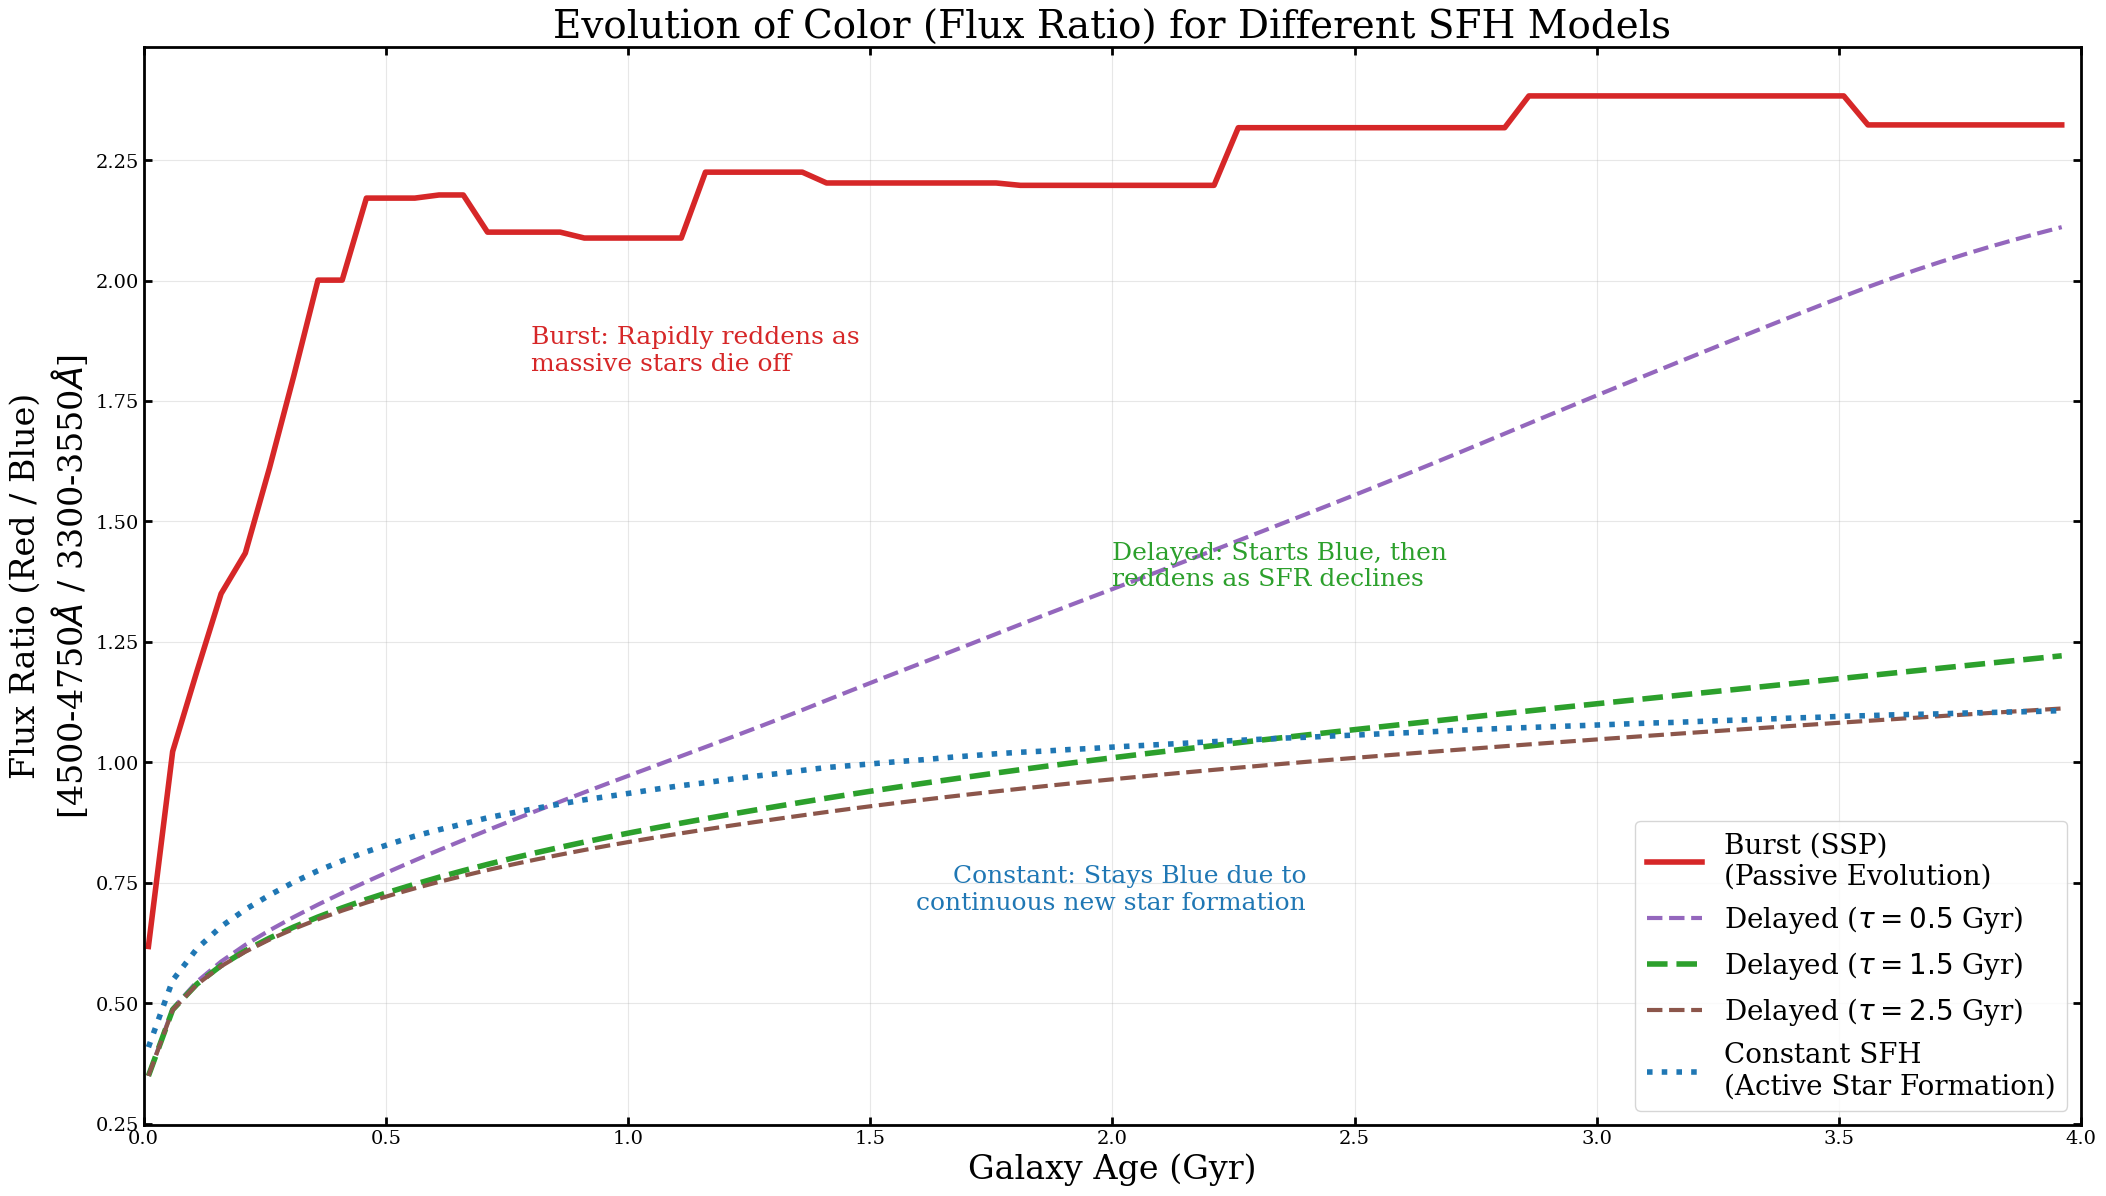

In [22]:
# --- 4. 绘图 ---
plt.figure(figsize=(25, 14))

# 设置线条样式
plt.plot(age_list, res_burst,    color='#d62728', linestyle='-',  linewidth=4, label='Burst (SSP)\n(Passive Evolution)')
plt.plot(age_list, res_delayed_05, color='#9467bd', linestyle='--', linewidth=3, label=r'Delayed ($\tau=0.5$ Gyr)')
plt.plot(age_list, res_delayed,  color='#2ca02c', linestyle='--', linewidth=4, label=r'Delayed ($\tau=1.5$ Gyr)')

plt.plot(age_list, res_delayed_25, color='#8c564b', linestyle='--', linewidth=3, label=r'Delayed ($\tau=2.5$ Gyr)')
plt.plot(age_list, res_constant, color='#1f77b4', linestyle=':',  linewidth=4, label='Constant SFH\n(Active Star Formation)')

# 装饰
plt.xlabel("Galaxy Age (Gyr)")
# 修改 Y 轴标签以匹配计算逻辑 (Red Integral / Blue Integral)
plt.ylabel(f"Flux Ratio (Red / Blue)\n[{r_left}-{r_right}$\AA$ / {b_left}-{b_right}$\AA$]")
plt.title("Evolution of Color (Flux Ratio) for Different SFH Models")

plt.legend( loc='best')
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=14)

# 添加注释文本帮助理解
plt.text(0.2, 0.7, "Burst: Rapidly reddens as\nmassive stars die off",
         transform=plt.gca().transAxes, fontsize=18, color='#d62728')

plt.text(0.6, 0.2, "Constant: Stays Blue due to\ncontinuous new star formation",
         transform=plt.gca().transAxes, fontsize=18, color='#1f77b4', ha='right')

plt.text(0.5, 0.5, "Delayed: Starts Blue, then\nreddens as SFR declines",
         transform=plt.gca().transAxes, fontsize=18, color='#2ca02c')

plt.xlim(0, 4.0)

# 反转 Y 轴逻辑检查：
# 目前计算的是 Red / Blue。
# Burst (红) -> R/B 应该很大。
# Constant (蓝) -> R/B 应该很小。
# 让我们确认一下代码中的 int_r / int_b。
# 如果想让 "蓝" 在上面，通常画 Blue/Red。
# 如果画 Red/Blue，那么曲线向上走代表变红。
# 看起来你的偏好是看“比值”，之前的代码是 int_r / int_b。
# 所以：曲线越高 = 越红。曲线越低 = 越蓝。
plt.savefig("bagpipes_SFH_color_evolution_comparison.pdf")
plt.show()

In [ ]:
import astropy
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
from scipy.signal import savgol_filter
import pandas as pd
import numpy as np
import FunctionLib as FL
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")


config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "legend.fontsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,
    "axes.edgecolor": "black",

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,
    "ytick.minor.width": 2,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)


DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(("./DJAV4.2Catalog.pkl"))

print("="*50)
print(f"Total {(DJAv4Catalog.sample_num())} sample objectss loaded.")
print("="*50)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import binned_statistic

# 设置绘图风格
mpl.rcParams.update({'font.size': 18, 'font.family': 'serif', 'axes.linewidth': 2,
                     'xtick.direction': 'in', 'ytick.direction': 'in', 'figure.figsize': (10, 8)})

z_list = []
dn_list = []

# 提取数据
for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
    if not entry['sample_flag']:
        continue
    try:
        m = entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']
        dn = m['red_flux_density'] / m['blue_flux_density']
        z = entry['determined_redshift']

        # 限制在合理的物理范围内，剔除极个别极端离群点
        if 0.1 < dn < 2.5 and 3.0 <= z <= 7.2:
            z_list.append(z)
            dn_list.append(dn)
    except:
        continue

z_array = np.array(z_list)
dn_array = np.array(dn_list)

# 计算 Running Median (滑动中位数) 展现趋势
z_bins = np.linspace(3.0, 7.2, 8)
bin_centers = 0.5 * (z_bins[1:] + z_bins[:-1])
dn_median, _, _ = binned_statistic(
    z_array, dn_array, statistic='median', bins=z_bins)
dn_err, _, _ = binned_statistic(
    z_array, dn_array, statistic=lambda x: np.std(x)/np.sqrt(len(x)), bins=z_bins)

fig, ax = plt.subplots(figsize=(12, 8))
# 画散点，用颜色表示 dn 值，直观呼应你曲线图的冷暖色调
scatter = ax.scatter(z_array, dn_array, c=dn_array, cmap='coolwarm',
                     alpha=0.5, edgecolor='k', s=60, vmin=0.3, vmax=0.85)

# 画滑动中位数
ax.errorbar(bin_centers, dn_median, yerr=dn_err, color='black', lw=3, marker='s', markersize=10,
            label='Running Median', capsize=5, zorder=10)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label(r'Flux Density Ratio $f_{4600}/f_{3400}$', fontsize=20)

ax.set_xlabel('Redshift ($z$)', fontsize=22)
ax.set_ylabel(r'Flux Density Ratio $f_{4600}/f_{3400}$', fontsize=22)
ax.set_title('Galaxy Evolutionary State vs. Cosmic Time', fontsize=24)
ax.set_xlim(2.8, 7.4)
ax.set_ylim(0.2, 1.8)
ax.legend(loc='upper right', fontsize=18)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('FluxRatio_vs_Redshift.pdf', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib as mpl
from astropy.cosmology import Planck18, z_at_value
import astropy.units as u
from scipy.interpolate import interp1d

# ==========================================
# 0. 全局字体与排版设置 (纯正 LaTeX 渲染)
# ==========================================
mpl.rcParams.update({"mathtext.fontset": "stix", "font.family": "serif"})
mpl.rcParams['text.usetex'] = True

# ==========================================
# 1. 模拟/真实观测数据 (请确保环境中已有 z_array, dn_array, 等变量)
# ==========================================
# (这里使用你环境中已经存在的 z_array, dn_array, bin_centers, dn_median, dn_err)

# ==========================================
# 3. 宇宙学时间映射与理论模型插值计算
# ==========================================
# 设定星系开始形成的红移
z_form = 20.0
t_form = Planck18.age(z_form).value  # 宇宙在 z=20 时的年龄 (Gyr)

# 生成平滑的观测红移网格用于画理论线
z_grid = np.linspace(2.8, 7.4, 200)
t_obs = Planck18.age(z_grid).value   # 观测红移处的宇宙年龄 (Gyr)

# 星系在观测红移处的最大可能年龄: t_max_gal(z_obs) = t_univ(z_obs) - t_univ(z_form)
t_max_gal = t_obs - t_form

# --- 【修改】：增加额外的 Delayed 模型插值 ---
interp_burst = interp1d(age_list, res_burst, bounds_error=False, fill_value='extrapolate')
interp_const = interp1d(age_list, res_constant, bounds_error=False, fill_value='extrapolate')
interp_delay_05 = interp1d(age_list, res_delayed_05, bounds_error=False, fill_value='extrapolate')
interp_delay = interp1d(age_list, res_delayed, bounds_error=False, fill_value='extrapolate')
interp_delay_25 = interp1d(age_list, res_delayed_25, bounds_error=False, fill_value='extrapolate')

ratio_burst_max = interp_burst(t_max_gal)
ratio_const_max = interp_const(t_max_gal)
ratio_delay_05_max = interp_delay_05(t_max_gal)
ratio_delay_max = interp_delay(t_max_gal)
ratio_delay_25_max = interp_delay_25(t_max_gal)

# ==========================================
# 4. 初始化画板与绘制观测散点 (统一单色)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8))

# 散点
scatter = ax.scatter(z_array, dn_array,
                     color='dodgerblue',
                     alpha=0.5,
                     edgecolor='k',
                     linewidth=0.5,
                     s=60,
                     zorder=1)

# 滑动中位数 (带有白色轮廓分离背景)
eb = ax.errorbar(bin_centers, dn_median, yerr=dn_err,
                 color='black', lw=3, marker='s', markersize=10,
                 elinewidth=3, capsize=6, capthick=3,
                 label='Observed Median', zorder=10)

white_halo =[pe.Stroke(linewidth=8, foreground='white', alpha=0.8), pe.Normal()]
eb[0].set_path_effects(white_halo)
for cap in eb[1]: cap.set_path_effects(white_halo)
for bar in eb[2]: bar.set_path_effects(white_halo)

# ==========================================
# 5. 叠加 Bagpipes 理论演化极限 (Models)
# ==========================================
# Burst (红色包络线: 理论最红极限)
ax.plot(z_grid, ratio_burst_max, color='#d62728', lw=4, ls='--',
        label=rf'Max Age Burst ($z_{{form}}={z_form}$)', zorder=5,
        path_effects=[pe.Stroke(linewidth=6, foreground='white', alpha=0.5), pe.Normal()])

# --- 【修改】：绘制三条 Delayed 演化线 ---
# Delayed tau = 0.5 (紫色)
ax.plot(z_grid, ratio_delay_05_max, color='#9467bd', lw=3, ls='-.',
        label=r'Max Age Delayed ($\tau=0.5\,\mathrm{Gyr}$)', zorder=5,
        path_effects=[pe.Stroke(linewidth=5, foreground='white', alpha=0.5), pe.Normal()])

# Delayed tau = 1.5 (绿色)
ax.plot(z_grid, ratio_delay_max, color='#2ca02c', lw=3, ls='-.',
        label=r'Max Age Delayed ($\tau=1.5\,\mathrm{Gyr}$)', zorder=5,
        path_effects=[pe.Stroke(linewidth=5, foreground='white', alpha=0.5), pe.Normal()])

# Delayed tau = 2.5 (棕色)
ax.plot(z_grid, ratio_delay_25_max, color='#8c564b', lw=3, ls='-.',
        label=r'Max Age Delayed ($\tau=2.5\,\mathrm{Gyr}$)', zorder=5,
        path_effects=[pe.Stroke(linewidth=5, foreground='white', alpha=0.5), pe.Normal()])

# Constant SFH (蓝色基线: 持续极蓝)
ax.plot(z_grid, ratio_const_max, color='#1f77b4', lw=4, ls=':',
        label=rf'Max Age Constant SFH', zorder=5,
        path_effects=[pe.Stroke(linewidth=6, foreground='white', alpha=0.5), pe.Normal()])

# ==========================================
# 6. 主坐标轴美化 (底部红移轴)
# ==========================================
ax.set_xlabel(r'Redshift $z$', fontsize=28)
ax.set_ylabel(r'Flux Density Ratio $f_{4600}/f_{3400}$', fontsize=28)

ax.set_xlim(2.8, 7.4)
ax.set_ylim(0.1, 1.8) # 视你的真实数据调整 Y 轴

# 开启全包围向内刻度
ax.minorticks_on()
ax.tick_params(axis='both', which='major', length=10, width=1.5, direction='in', right=True)
ax.tick_params(axis='both', which='minor', length=5, width=1, direction='in', right=True)
ax.grid(True, alpha=0.15, zorder=0)

# ==========================================
# 7. 顶部宇宙年龄坐标轴 (Cosmic Time)
# ==========================================
ax2 = ax.twiny()

# 你希望在顶部显示的宇宙年龄刻度 (Gyr)
age_ticks = np.array([0.7, 1.0, 1.5, 2.0])
z_ticks =[z_at_value(Planck18.age, age * u.Gyr).value for age in age_ticks]

ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(z_ticks)
ax2.set_xticklabels([f'${t:.1f}$' for t in age_ticks], fontsize=20)
ax2.set_xlabel(r'Cosmic Time ($\mathrm{Gyr}$)', fontsize=28, labelpad=10)

ax2.minorticks_on()
ax2.tick_params(axis='x', which='major', length=10, width=1.5, direction='in')
ax2.tick_params(axis='x', which='minor', length=5, width=1, direction='in')

# ==========================================
# 8. 图例与保存
# ==========================================
ax.legend(loc='upper right',
          fontsize=16, # 图例项变多了，字体稍微调小一点防止太挤
          framealpha=0.9,
          edgecolor='none')

plt.tight_layout()
plt.savefig('FluxRatio_vs_Redshift_MultiDelayed.pdf', dpi=300, bbox_inches='tight')
plt.show()